In [1]:
import os
import sys
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_dir = Path("Deep-Learning-Project-Tuwaiq")
    if not repo_dir.is_dir():
        !git clone https://github.com/khaliddosari/Deep-Learning-Project-Tuwaiq.git
    os.chdir(repo_dir)

In [2]:
def find_project_root(start: Path) -> Path:
    for base in (start, *start.parents):
        if (base / "src" / "config.py").is_file():
            return base
    for child in sorted(c for c in start.iterdir() if c.is_dir()):
        if (child / "src" / "config.py").is_file():
            return child
    raise RuntimeError(f"Could not find the project root from {start}.")

ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"Project root: {ROOT}")

Project root: /mnt/c/Users/Khalid/Downloads/Coding Projects/Deep-Learning-Project-Tuwaiq


In [3]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

I0000 00:00:1787404700.060849  102727 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787404701.252344  102727 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787404717.034860  102727 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1787404733.400597  102727 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

from src.config import IMG_SHAPE, NUM_CLASSES, SEED
from src.data import load_splits
from src.models import build_dense_model, validate_model
from src.utils import set_seed

set_seed(SEED)

data = load_splits()

print(data.summary())

X_train  (45000, 32, 32, 3)  float32
X_val    (5000, 32, 32, 3)   float32
X_test   (10000, 32, 32, 3)  float32
y_train  (45000,)            int32
y_val    (5000,)             int32
y_test   (10000,)            int32


In [5]:
HIDDEN_UNITS = [512, 512, 512]

LEARNING_RATE = 0.0001
BATCH_SIZE = 128
EPOCHS = 50

print("Selected architecture:", HIDDEN_UNITS)
print("Learning rate:", LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

Selected architecture: [512, 512, 512]
Learning rate: 0.0001
Batch size: 128
Epochs: 50


In [6]:
baseline_model = build_dense_model(
    hidden_units=HIDDEN_UNITS,
    learning_rate=LEARNING_RATE,
    optimizer="adam",
    seed=SEED,
    name="medium_baseline"
)

baseline_model.summary()

W0000 00:00:1787404735.083118  102727 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1787404735.274115  102727 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5219 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "medium_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,103,818 (8.03 MB)

 Trainable params: 2,103,818 (8.03 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
set_seed(SEED)

baseline_model = build_dense_model(
    hidden_units=HIDDEN_UNITS,
    learning_rate=LEARNING_RATE,
    seed=SEED,
    name="medium_baseline"
)

baseline_history = baseline_model.fit(
    data.X_train,
    data.y_train,
    validation_data=(data.X_val, data.y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/50


I0000 00:00:1787404738.224453  103361 service.cc:153] XLA service 0x78bfdc046590 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787404738.224482  103361 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1787404738.276715  103361 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787404738.423320  103361 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1787404738.444104  103361 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1653__.14
I0000 00:00:1787404739.847908  103438 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1787404740.919922  103440 subprocess_compilation.cc:348] ptxas warni

 75/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2500 - loss: 2.0543

I0000 00:00:1787404744.646652  103361 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


327/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3378 - loss: 1.8565

I0000 00:00:1787404745.440135  103362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1653__.14
I0000 00:00:1787404745.964511  103632 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1787404746.380221  103635 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1787404746.391227  103632 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1787404746.768337  103633 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1787404747.064661  103630 subprocess_compilatio

352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3429 - loss: 1.8437

I0000 00:00:1787404752.296249  103855 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 4 bytes spill stores, 4 bytes spill loads



352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.3429 - loss: 1.8437 - val_accuracy: 0.3946 - val_loss: 1.6932
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4193 - loss: 1.6370 - val_accuracy: 0.4306 - val_loss: 1.6044
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4512 - loss: 1.5522 - val_accuracy: 0.4516 - val_loss: 1.5545
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4723 - loss: 1.4909 - val_accuracy: 0.4608 - val_loss: 1.5239
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4908 - loss: 1.4399 - val_accuracy: 0.4748 - val_loss: 1.4964
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5078 - loss: 1.3961 - val_accuracy: 0.4838 - val_loss: 1.4679
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5217 - loss: 1.3562 - val_accuracy: 0.4900 - val_loss: 1.4549
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5351 - loss: 1.3199 - val_accuracy: 0.4968 - va

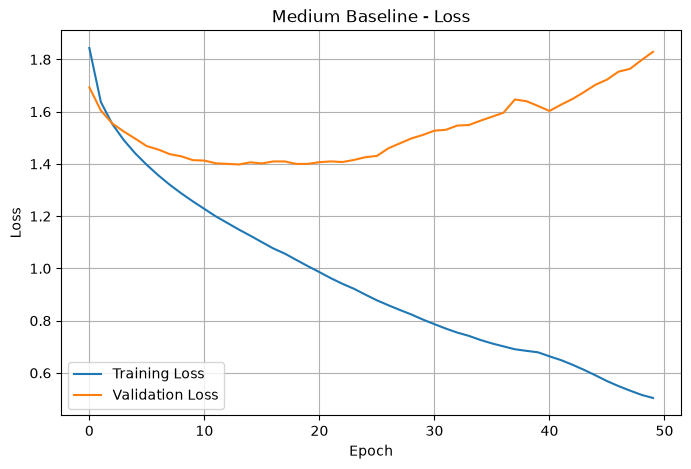

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(baseline_history.history["loss"], label="Training Loss")
plt.plot(baseline_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Medium Baseline - Loss")
plt.legend()
plt.grid(True)
plt.show()

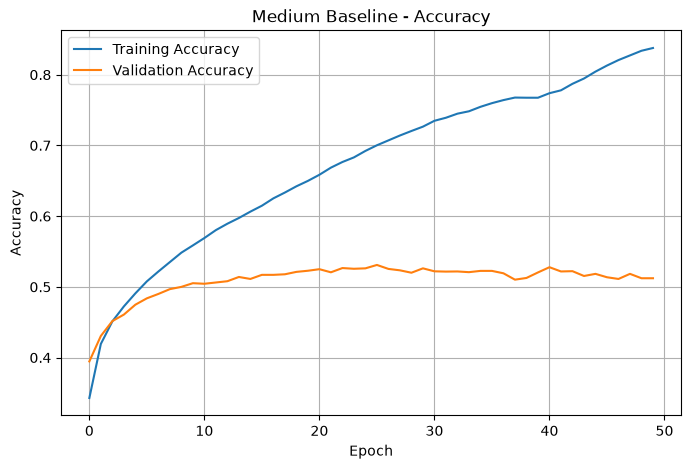

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(baseline_history.history["accuracy"], label="Training Accuracy")
plt.plot(baseline_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Medium Baseline - Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
best_val_acc = max(baseline_history.history["val_accuracy"])
best_val_acc_epoch = (
    baseline_history.history["val_accuracy"].index(best_val_acc) + 1
)

min_val_loss = min(baseline_history.history["val_loss"])
min_val_loss_epoch = (
    baseline_history.history["val_loss"].index(min_val_loss) + 1
)

final_train_acc = baseline_history.history["accuracy"][-1]
final_val_acc = baseline_history.history["val_accuracy"][-1]

final_train_loss = baseline_history.history["loss"][-1]
final_val_loss = baseline_history.history["val_loss"][-1]

print("===== MEDIUM BASELINE =====")
print(f"Best Validation Accuracy : {best_val_acc:.4f}")
print(f"Best Validation Acc Epoch: {best_val_acc_epoch}")
print(f"Minimum Validation Loss  : {min_val_loss:.4f}")
print(f"Minimum Val Loss Epoch   : {min_val_loss_epoch}")
print(f"Final Training Accuracy  : {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss      : {final_train_loss:.4f}")
print(f"Final Validation Loss    : {final_val_loss:.4f}")

===== MEDIUM BASELINE =====
Best Validation Accuracy : 0.5310
Best Validation Acc Epoch: 26
Minimum Validation Loss  : 1.3979
Minimum Val Loss Epoch   : 14
Final Training Accuracy  : 0.8378
Final Validation Accuracy: 0.5122
Final Training Loss      : 0.5040
Final Validation Loss    : 1.8291


### PART9-17

# Part 9 - Learning Rate Experiment

We test different learning rates while keeping the selected Medium architecture
[512, 512, 512] and all other hyperparameters unchanged.


In [11]:
# Load the same train/validation/test split used throughout the project

splits = load_splits()

X_train = splits.X_train
y_train = splits.y_train

X_val = splits.X_val
y_val = splits.y_val

X_test = splits.X_test
y_test = splits.y_test

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (45000, 32, 32, 3)
X_val: (5000, 32, 32, 3)
X_test: (10000, 32, 32, 3)
y_train: (45000,)
y_val: (5000,)
y_test: (10000,)


In [12]:
# Part 9 - Learning Rate Experiment

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt

# Fixed settings from the selected Medium architecture
HIDDEN_UNITS = [512, 512, 512]
BATCH_SIZE = 128
EPOCHS = 50

LEARNING_RATES = [0.01, 0.001, 0.0001]

print("Architecture:", HIDDEN_UNITS)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rates:", LEARNING_RATES)

Architecture: [512, 512, 512]
Batch size: 128
Epochs: 50
Learning rates: [0.01, 0.001, 0.0001]


In [13]:
def build_medium_model(learning_rate):

    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [14]:
learning_rate_results = {}
learning_rate_histories = {}

for lr in LEARNING_RATES:

    print("\n" + "=" * 60)
    print(f"Training with Learning Rate = {lr}")
    print("=" * 60)

    # Fresh model = fresh weights
    model = build_medium_model(lr)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        verbose=1
    )

    learning_rate_histories[lr] = history.history

    best_val_acc = max(history.history["val_accuracy"])
    best_val_acc_epoch = (
        history.history["val_accuracy"].index(best_val_acc) + 1
    )

    min_val_loss = min(history.history["val_loss"])
    min_val_loss_epoch = (
        history.history["val_loss"].index(min_val_loss) + 1
    )

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]

    final_train_loss = history.history["loss"][-1]
    final_val_loss = history.history["val_loss"][-1]

    learning_rate_results[lr] = {
        "Best Val Accuracy": best_val_acc,
        "Best Val Accuracy Epoch": best_val_acc_epoch,
        "Minimum Val Loss": min_val_loss,
        "Minimum Val Loss Epoch": min_val_loss_epoch,
        "Final Train Accuracy": final_train_acc,
        "Final Val Accuracy": final_val_acc,
        "Final Train Loss": final_train_loss,
        "Final Val Loss": final_val_loss
    }

    print(f"Best Validation Accuracy : {best_val_acc:.4f}")
    print(f"Best Validation Acc Epoch: {best_val_acc_epoch}")
    print(f"Minimum Validation Loss  : {min_val_loss:.4f}")
    print(f"Minimum Val Loss Epoch   : {min_val_loss_epoch}")
    print(f"Final Training Accuracy  : {final_train_acc:.4f}")
    print(f"Final Validation Accuracy: {final_val_acc:.4f}")


Training with Learning Rate = 0.01


/mnt/c/Users/Khalid/Downloads/Coding Projects/Deep-Learning-Project-Tuwaiq/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


I0000 00:00:1787404798.631891  103361 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_83075__.14


349/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2491 - loss: 2.6624

...

352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3254 - loss: 1.8594 - val_accuracy: 0.3922 - val_loss: 1.7101
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4039 - loss: 1.6630 - val_accuracy: 0.4202 - val_loss: 1.6389
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4386 - loss: 1.5655 - val_accuracy: 0.4398 - val_loss: 1.5875
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4598 - loss: 1.5077 - val_accuracy: 0.4572 - val_loss: 1.5440
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4776 - loss: 1.4592 - val_accuracy: 0.4612 - val_loss: 1.5443
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4944 - loss: 1.4193 - val_accuracy: 0.4712 - val_loss: 1.5382
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5050 - loss: 1.3813 - val_accuracy: 0.4722 - val_loss: 1.5351
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5175 - loss: 1.3481 - val_accuracy: 0.4674 - val_

I0000 00:00:1787404890.949402  103359 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_245919__.14


350/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3407 - loss: 1.8468

I0000 00:00:1787404892.696285  103359 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_245919__.14


352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3411 - loss: 1.8459 - val_accuracy: 0.3988 - val_loss: 1.6997
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4185 - loss: 1.6405 - val_accuracy: 0.4296 - val_loss: 1.6142
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4485 - loss: 1.5550 - val_accuracy: 0.4510 - val_loss: 1.5628
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4704 - loss: 1.4947 - val_accuracy: 0.4644 - val_loss: 1.5228
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4875 - loss: 1.4444 - val_accuracy: 0.4758 - val_loss: 1.4979
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5057 - loss: 1.4004 - val_accuracy: 0.4856 - val_loss: 1.4882
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5179 - loss: 1.3623 - val_accuracy: 0.4914 - val_loss: 1.4681
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5333 - loss: 1.3264 - val_accuracy: 0.4934 - val_

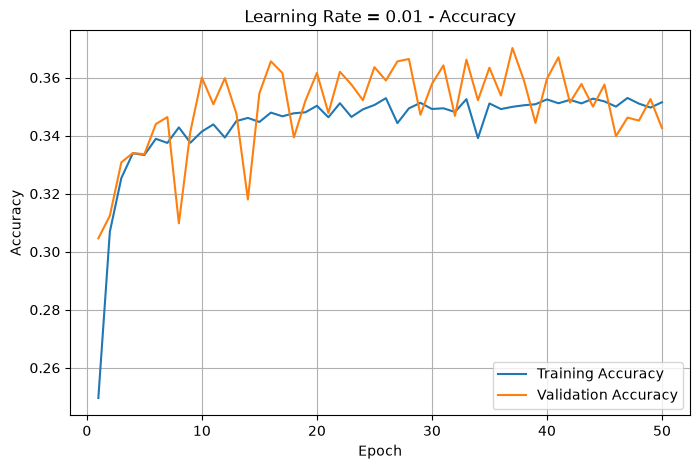

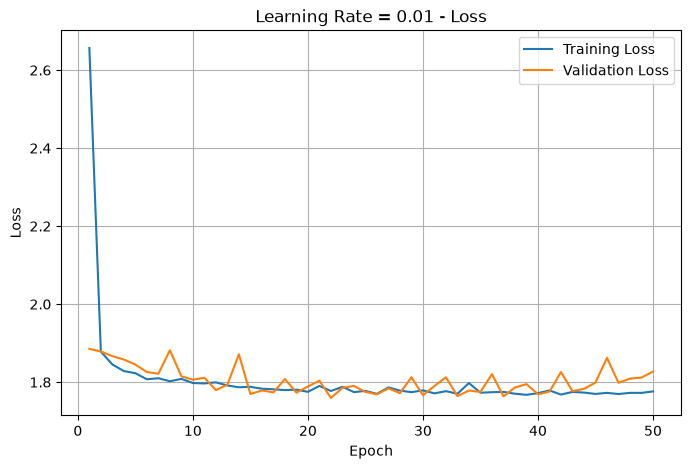

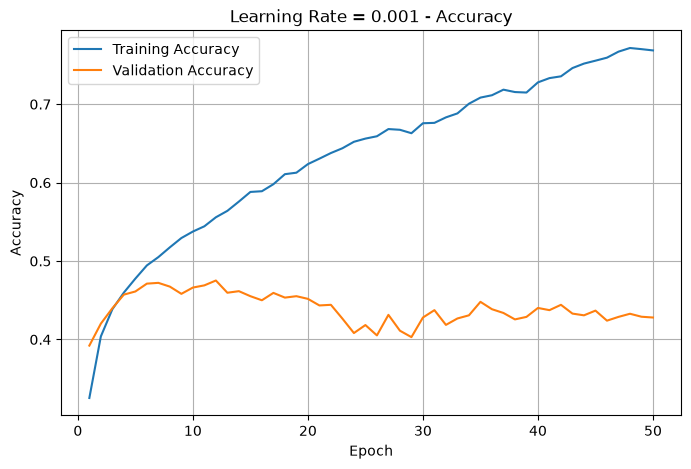

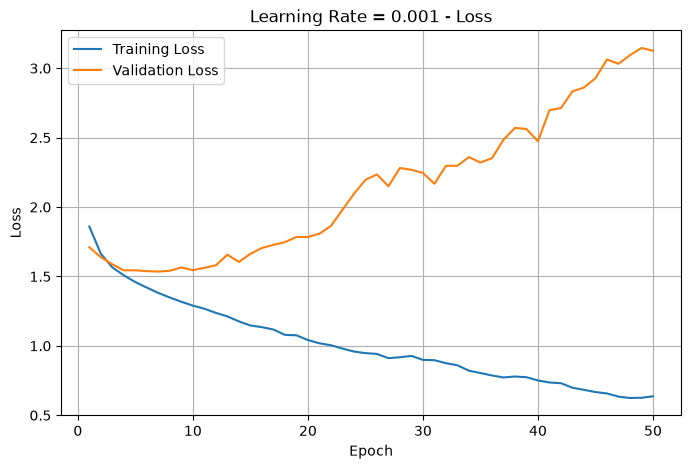

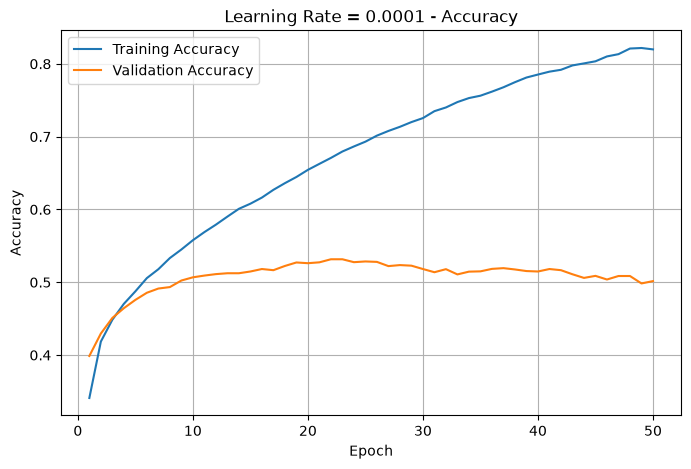

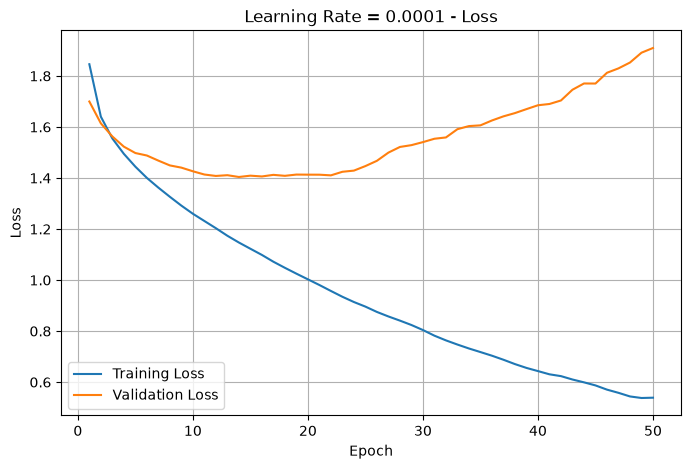

In [15]:
# Part 9 - Learning Curves for Each Learning Rate

for lr, history in learning_rate_histories.items():

    epochs_range = range(1, len(history["accuracy"]) + 1)

    # Accuracy curve
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs_range,
        history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        epochs_range,
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Learning Rate = {lr} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss curve
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs_range,
        history["loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs_range,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Learning Rate = {lr} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

In [16]:
# Part 9 - Learning Rate Results Summary

import pandas as pd

learning_rate_df = pd.DataFrame(learning_rate_results).T

learning_rate_df

,Best Val Accuracy,Best Val Accuracy Epoch,Minimum Val Loss,Minimum Val Loss Epoch,Final Train Accuracy,Final Val Accuracy,Final Train Loss,Final Val Loss
0.0100,0.3702,37.0,1.759454,22.0,0.351511,0.3426,1.776283,1.827281
0.0010,0.4752,12.0,1.535064,7.0,0.768600,0.4280,0.636682,3.125862
0.0001,0.5316,22.0,1.404003,14.0,0.819844,0.5016,0.538994,1.909520


In [17]:
# Select the best learning rate based on validation accuracy

best_learning_rate = max(
    learning_rate_results,
    key=lambda lr: learning_rate_results[lr]["Best Val Accuracy"]
)

print("Best Learning Rate:", best_learning_rate)
print(
    "Best Validation Accuracy:",
    learning_rate_results[best_learning_rate]["Best Val Accuracy"]
)

Best Learning Rate: 0.0001
Best Validation Accuracy: 0.5315999984741211


The learning rate of 0.0001 is the most appropriate for the model. It achieved the highest validation accuracy of 53.16%, compared with 47.52% for 0.001 and 37.02% for 0.01. It also achieved the lowest minimum validation loss of 1.4040, indicating the best validation performance among the three learning rates.

The learning curves show that 0.0001 provided slower but more consistent learning, reaching its best validation accuracy at epoch 22. In contrast, 0.01 learned too aggressively and never exceeded 37.02% validation accuracy, while 0.001 reached its best validation accuracy as early as epoch 12 and then diverged sharply, ending with a validation loss of 3.1259. Therefore, 0.0001 was selected as the most appropriate learning rate for the next optimization experiments because it achieved the highest validation accuracy and lowest validation loss


### Batch Size

In [18]:
# Part 10 - Batch Size Experiment

BATCH_SIZES = [16, 32, 64, 128]

BEST_LEARNING_RATE = 0.0001

print("Batch sizes:", BATCH_SIZES)
print("Learning rate:", BEST_LEARNING_RATE)
print("Architecture:", [512, 512, 512])

Batch sizes: [16, 32, 64, 128]
Learning rate: 0.0001
Architecture: [512, 512, 512]


In [19]:
batch_size_results = {}
batch_size_histories = {}

for batch_size in BATCH_SIZES:

    print("\n" + "=" * 60)
    print(f"Training with Batch Size = {batch_size}")
    print("=" * 60)

    # Fresh model with new weights
    model = build_medium_model(BEST_LEARNING_RATE)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        batch_size=batch_size,
        epochs=EPOCHS,
        verbose=1
    )

    batch_size_histories[batch_size] = history.history

    best_val_acc = max(history.history["val_accuracy"])
    best_val_acc_epoch = (
        history.history["val_accuracy"].index(best_val_acc) + 1
    )

    min_val_loss = min(history.history["val_loss"])
    min_val_loss_epoch = (
        history.history["val_loss"].index(min_val_loss) + 1
    )

    batch_size_results[batch_size] = {
        "Best Val Accuracy": best_val_acc,
        "Best Val Accuracy Epoch": best_val_acc_epoch,
        "Minimum Val Loss": min_val_loss,
        "Minimum Val Loss Epoch": min_val_loss_epoch,
        "Final Train Accuracy": history.history["accuracy"][-1],
        "Final Val Accuracy": history.history["val_accuracy"][-1],
        "Final Train Loss": history.history["loss"][-1],
        "Final Val Loss": history.history["val_loss"][-1]
    }

    print(f"Best Validation Accuracy : {best_val_acc:.4f}")
    print(f"Best Validation Acc Epoch: {best_val_acc_epoch}")
    print(f"Minimum Validation Loss  : {min_val_loss:.4f}")


Training with Batch Size = 16


/mnt/c/Users/Khalid/Downloads/Coding Projects/Deep-Learning-Project-Tuwaiq/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


I0000 00:00:1787404938.953564  103362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_327341__.14
I0000 00:00:1787404940.042811  115898 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 4 bytes spill stores, 4 bytes spill loads



2795/2813 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3491 - loss: 1.8029

...

704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.3499 - loss: 1.8234 - val_accuracy: 0.3888 - val_loss: 1.7025
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4227 - loss: 1.6224 - val_accuracy: 0.4270 - val_loss: 1.6127
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4554 - loss: 1.5372 - val_accuracy: 0.4484 - val_loss: 1.5686
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4797 - loss: 1.4720 - val_accuracy: 0.4688 - val_loss: 1.5344
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4972 - loss: 1.4186 - val_accuracy: 0.4706 - val_loss: 1.5251
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5147 - loss: 1.3720 - val_accuracy: 0.4782 - val_loss: 1.4999
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5319 - loss: 1.3289 - val_accuracy: 0.4864 - val_loss: 1.4777
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5448 - loss: 1.2894 - val_accuracy: 0.4912 - val_

I0000 00:00:1787405479.478578  103362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1431007__.14


348/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3442 - loss: 1.8391

I0000 00:00:1787405481.182104  103360 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1431007__.14


352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3445 - loss: 1.8379 - val_accuracy: 0.3916 - val_loss: 1.7020
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4201 - loss: 1.6361 - val_accuracy: 0.4298 - val_loss: 1.6180
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4493 - loss: 1.5532 - val_accuracy: 0.4406 - val_loss: 1.5844
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4726 - loss: 1.4910 - val_accuracy: 0.4538 - val_loss: 1.5539
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4893 - loss: 1.4423 - val_accuracy: 0.4672 - val_loss: 1.5267
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5076 - loss: 1.3982 - val_accuracy: 0.4808 - val_loss: 1.5010
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5215 - loss: 1.3588 - val_accuracy: 0.4856 - val_loss: 1.4885
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5340 - loss: 1.3224 - val_accuracy: 0.4926 - val_

In [20]:
batch_size_df = pd.DataFrame(batch_size_results).T
batch_size_df

,Best Val Accuracy,Best Val Accuracy Epoch,Minimum Val Loss,Minimum Val Loss Epoch,Final Train Accuracy,Final Val Accuracy,Final Train Loss,Final Val Loss
16,0.4978,11.0,1.463865,8.0,0.942089,0.4864,0.172650,3.416019
32,0.5046,15.0,1.438745,8.0,0.918911,0.4958,0.251384,2.815125
64,0.5182,36.0,1.422097,13.0,0.872867,0.5018,0.384736,2.289302
128,0.5214,44.0,1.409286,14.0,0.828911,0.5090,0.520232,1.841846


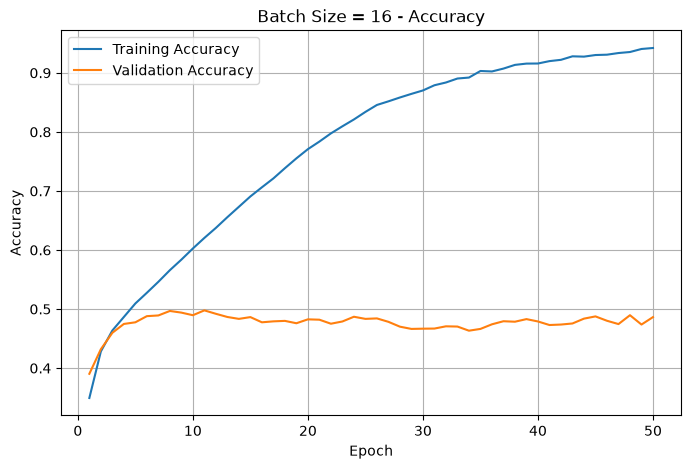

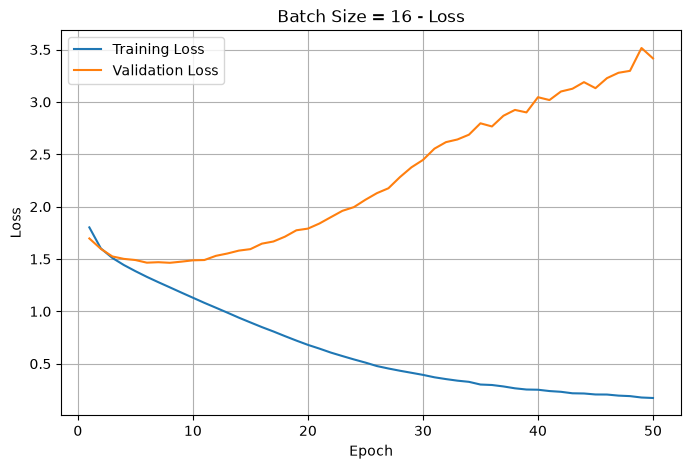

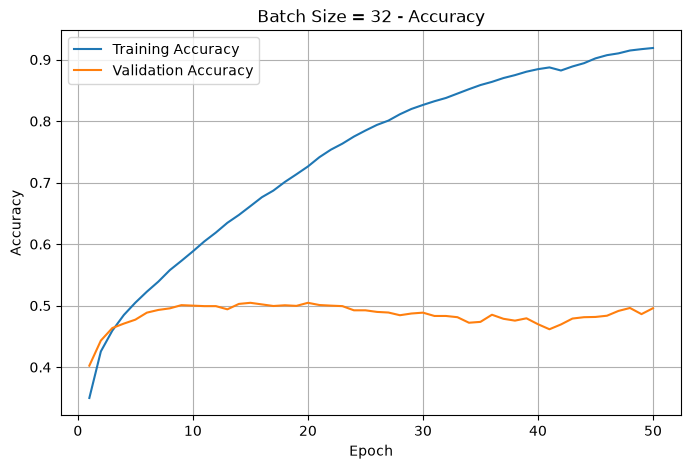

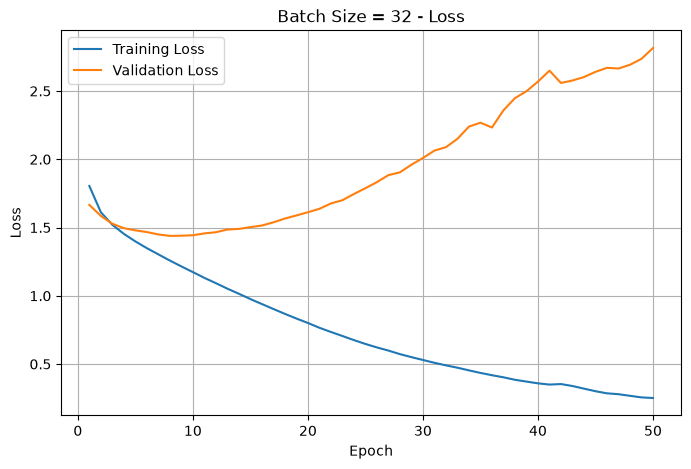

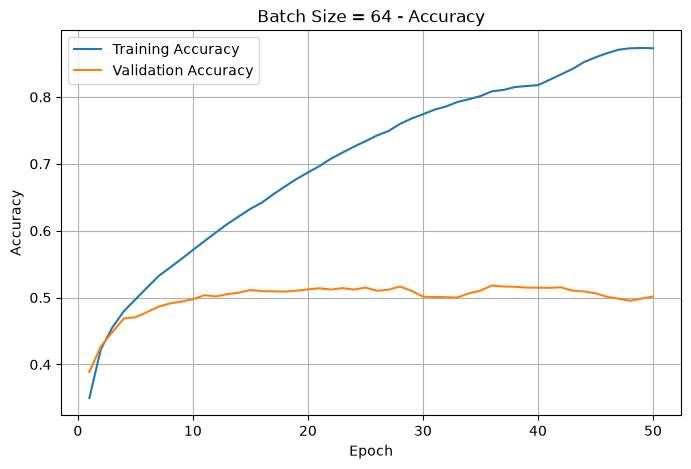

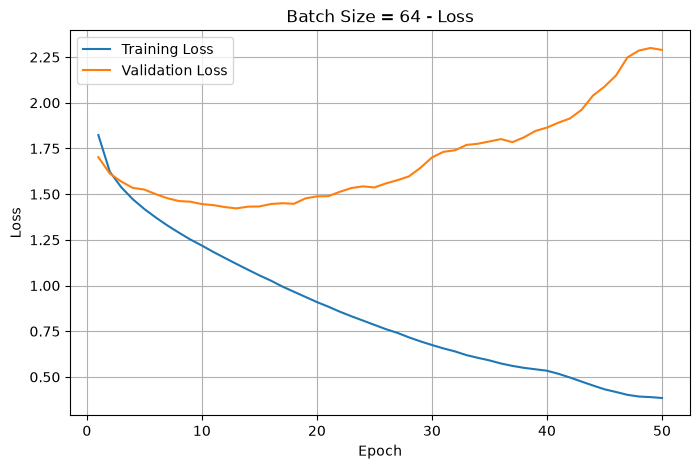

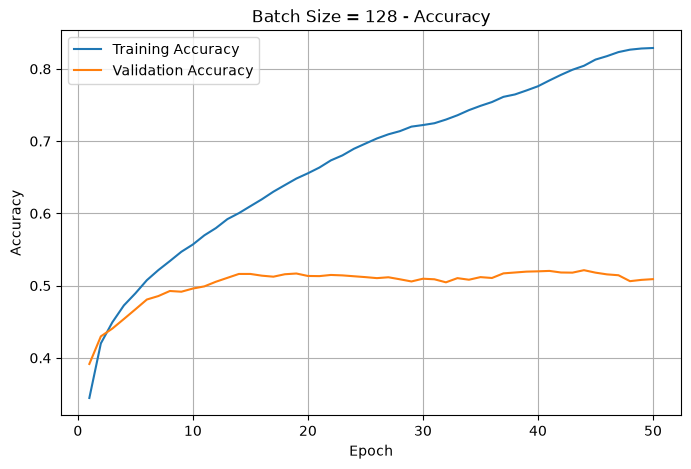

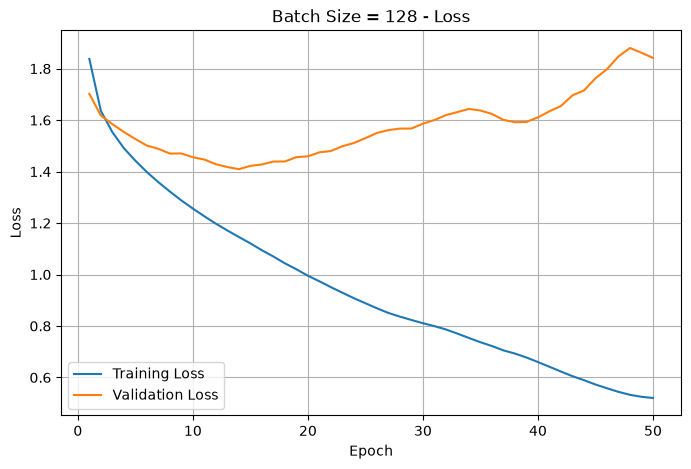

In [21]:
for batch_size, history in batch_size_histories.items():

    epochs_range = range(1, len(history["accuracy"]) + 1)

    # Accuracy
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs_range,
        history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        epochs_range,
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Batch Size = {batch_size} - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs_range,
        history["loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs_range,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Batch Size = {batch_size} - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

1. Which Batch Size produced the best result?

Batch Size 128 produced the best overall result. It achieved the highest validation accuracy (52.14%) and the lowest minimum validation loss (1.4093) among the tested batch sizes.

2. Did increasing Batch Size automatically improve the model?

Not automatically, but in this experiment the trend was consistent: 16 reached 49.78%, 32 reached 50.46%, 64 reached 51.82% and 128 reached 52.14%. Validation accuracy improved at every step and minimum validation loss fell at every step, so within the range tested the larger batch was always the better choice. The gain from 64 to 128 was only 0.32 points, however, which is inside the noise of a 5,000-image validation set, so the advantage over 64 is not clearly established.

3. What effect did Batch Size have on the learning curves?

The clearest effect was on overfitting. Smaller batches perform more weight updates per epoch and drove training accuracy much higher within the fixed 50 epochs, reaching 94.21% at batch 16 against 82.89% at batch 128, while validation accuracy moved in the opposite direction. The smaller batches also diverged much harder: final validation loss was 3.4160 at batch 16 against 1.8418 at batch 128, and they reached their minimum validation loss as early as epoch 8, compared with epoch 14 for batch 128. Larger batches therefore trained more slowly but generalized better here.


### Optimizer Experiment

In [22]:
# Part 11 - Optimizer Experiment
OPTIMIZERS = {
    "Adam": 0.0001,
    "SGD": 0.01
}

BEST_BATCH_SIZE = 128

optimizer_results = {}
optimizer_histories = {}

print("Optimizers:", OPTIMIZERS)
print("Batch size:", BEST_BATCH_SIZE)
print("Architecture:", [512, 512, 512])
print("Epochs:", EPOCHS)

Optimizers: {'Adam': 0.0001, 'SGD': 0.01}
Batch size: 128
Architecture: [512, 512, 512]
Epochs: 50


In [53]:
def build_optimizer_model(optimizer_name, learning_rate):

    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    if optimizer_name == "Adam":

        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer_name == "SGD":

        optimizer = keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [54]:
for optimizer_name, learning_rate in OPTIMIZERS.items():

    print("\n" + "=" * 60)
    print(f"Training with Optimizer = {optimizer_name}")
    print(f"Learning Rate = {learning_rate}")
    print("=" * 60)

    # Fresh model with fresh weights
    model = build_optimizer_model(
        optimizer_name,
        learning_rate
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        batch_size=BEST_BATCH_SIZE,
        epochs=EPOCHS,
        verbose=1
    )

    optimizer_histories[optimizer_name] = history.history

    best_val_acc = max(history.history["val_accuracy"])
    best_val_acc_epoch = (
        history.history["val_accuracy"].index(best_val_acc) + 1
    )

    min_val_loss = min(history.history["val_loss"])
    min_val_loss_epoch = (
        history.history["val_loss"].index(min_val_loss) + 1
    )

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]

    final_train_loss = history.history["loss"][-1]
    final_val_loss = history.history["val_loss"][-1]

    optimizer_results[optimizer_name] = {
        "Learning Rate": learning_rate,
        "Best Val Accuracy": best_val_acc,
        "Best Val Accuracy Epoch": best_val_acc_epoch,
        "Minimum Val Loss": min_val_loss,
        "Minimum Val Loss Epoch": min_val_loss_epoch,
        "Final Train Accuracy": final_train_acc,
        "Final Val Accuracy": final_val_acc,
        "Final Train Loss": final_train_loss,
        "Final Val Loss": final_val_loss
    }

    print(f"Best Validation Accuracy : {best_val_acc:.4f}")
    print(f"Best Validation Acc Epoch: {best_val_acc_epoch}")
    print(f"Minimum Validation Loss  : {min_val_loss:.4f}")
    print(f"Minimum Val Loss Epoch   : {min_val_loss_epoch}")
    print(f"Final Training Accuracy  : {final_train_acc:.4f}")
    print(f"Final Validation Accuracy: {final_val_acc:.4f}")
    print(f"Final Training Loss      : {final_train_loss:.4f}")
    print(f"Final Validation Loss    : {final_val_loss:.4f}")


Training with Optimizer = Adam
Learning Rate = 0.0001


/mnt/c/Users/Khalid/Downloads/Coding Projects/Deep-Learning-Project-Tuwaiq/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


I0000 00:00:1787407751.126848  103359 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2800126__.14


350/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3443 - loss: 1.8411

...

352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3447 - loss: 1.8402 - val_accuracy: 0.3898 - val_loss: 1.6950
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4189 - loss: 1.6383 - val_accuracy: 0.4356 - val_loss: 1.6074
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4484 - loss: 1.5546 - val_accuracy: 0.4508 - val_loss: 1.5640
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4706 - loss: 1.4937 - val_accuracy: 0.4624 - val_loss: 1.5311
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4895 - loss: 1.4426 - val_accuracy: 0.4704 - val_loss: 1.5079
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5076 - loss: 1.3993 - val_accuracy: 0.4824 - val_loss: 1.4865
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5215 - loss: 1.3600 - val_accuracy: 0.4872 - val_loss: 1.4665
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5332 - loss: 1.3251 - val_accuracy: 0.4918 - val_

I0000 00:00:1787407798.667990  103360 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2880620__.14


350/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2820 - loss: 2.0121

I0000 00:00:1787407801.710229  103358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2880620__.14
I0000 00:00:1787407801.926857  185980 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_30', 12 bytes spill stores, 60 bytes spill loads

I0000 00:00:1787407802.511066  185973 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_6', 4 bytes spill stores, 4 bytes spill loads



352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.2821 - loss: 2.0115 - val_accuracy: 0.3104 - val_loss: 1.8983
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3571 - loss: 1.8227 - val_accuracy: 0.3500 - val_loss: 1.8124
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3836 - loss: 1.7500 - val_accuracy: 0.3624 - val_loss: 1.7675
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4020 - loss: 1.6983 - val_accuracy: 0.3716 - val_loss: 1.7430
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4171 - loss: 1.6573 - val_accuracy: 0.3814 - val_loss: 1.7265
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4294 - loss: 1.6225 - val_accuracy: 0.3866 - val_loss: 1.7108
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4400 - loss: 1.5922 - val_accuracy: 0.3952 - val_loss: 1.6933
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4496 - loss: 1.5657 - val_accuracy: 0.4018 - val

In [55]:
optimizer_df = pd.DataFrame(optimizer_results).T
optimizer_df

,Learning Rate,Best Val Accuracy,Best Val Accuracy Epoch,Minimum Val Loss,Minimum Val Loss Epoch,Final Train Accuracy,Final Val Accuracy,Final Train Loss,Final Val Loss
Adam,0.0001,0.5256,29.0,1.395727,16.0,0.822467,0.5202,0.539679,1.785483
SGD,0.0100,0.5030,49.0,1.459208,47.0,0.649711,0.4984,1.014409,1.479204


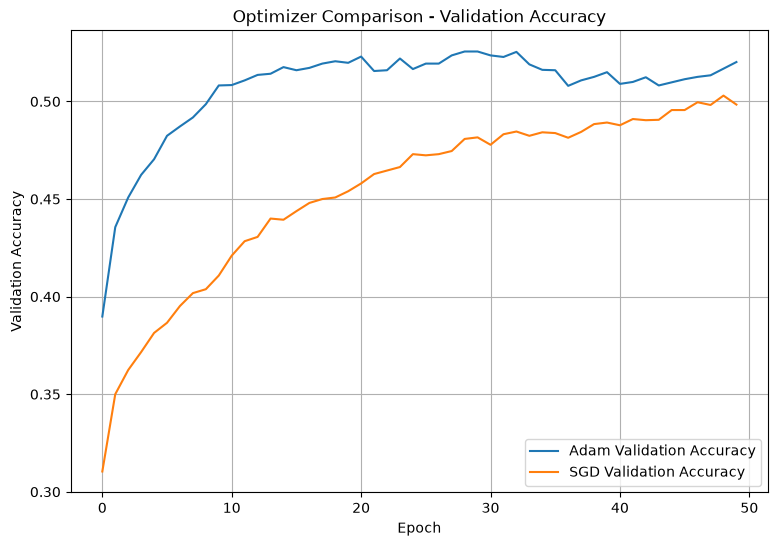

In [56]:
plt.figure(figsize=(9, 6))

for optimizer_name, history in optimizer_histories.items():

    plt.plot(
        history["val_accuracy"],
        label=f"{optimizer_name} Validation Accuracy"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison - Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

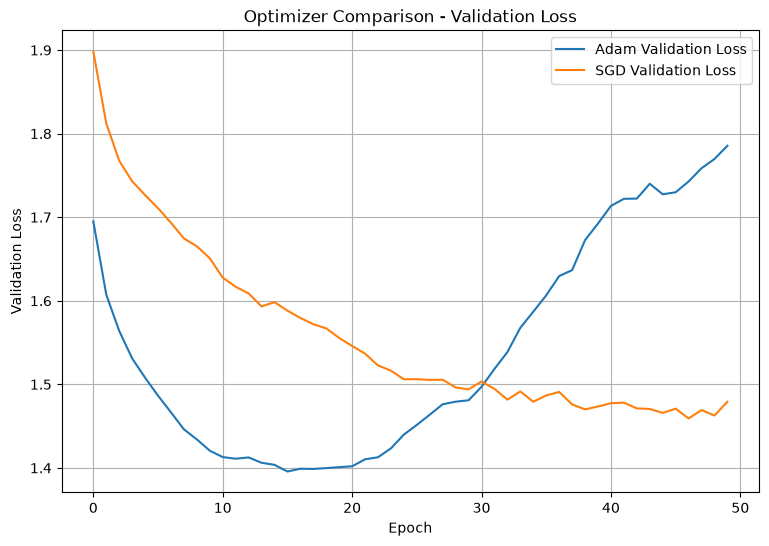

In [57]:
plt.figure(figsize=(9, 6))

for optimizer_name, history in optimizer_histories.items():

    plt.plot(
        history["val_loss"],
        label=f"{optimizer_name} Validation Loss"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Optimizer Comparison - Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Adam and SGD were compared using the same model architecture, batch size, training data, and 50 training epochs. Adam used a learning rate of 0.0001, while SGD used 0.01.

Adam achieved a higher best validation accuracy of 52.56%, compared with 50.30% for SGD. It also achieved a lower minimum validation loss of 1.3957, compared with 1.4592 for SGD, and reached its best validation accuracy at epoch 29, while SGD was still improving and reached its best only at epoch 49. Adam therefore converged considerably sooner.

SGD did finish with the lower final validation loss (1.4792 against 1.7855). This is because Adam kept fitting the training data after its best epoch, ending at 82.25% training accuracy against 64.97% for SGD, so the difference reflects how far each optimizer overfitted by epoch 50 rather than the quality of the best model each one reached. Therefore, Adam was selected as the preferred optimizer for this experiment because it provided the highest validation accuracy, the lowest minimum validation loss, and faster convergence, with Early Stopping available to recover its best epoch.


### Regularization Experiments

In [28]:
# Part 12 - Regularization Experiments
# Experiment A - Baseline
# No additional regularization

def build_baseline_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


baseline_model = build_baseline_model()

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    verbose=1
)

/mnt/c/Users/Khalid/Downloads/Coding Projects/Deep-Learning-Project-Tuwaiq/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


I0000 00:00:1787405631.554186  103362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1674313__.14


330/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3383 - loss: 1.8620

I0000 00:00:1787405633.251214  103359 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1674313__.14


352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3421 - loss: 1.8518 - val_accuracy: 0.3970 - val_loss: 1.7045
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4183 - loss: 1.6435 - val_accuracy: 0.4280 - val_loss: 1.6201
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4481 - loss: 1.5581 - val_accuracy: 0.4432 - val_loss: 1.5723
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4717 - loss: 1.4962 - val_accuracy: 0.4546 - val_loss: 1.5468
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4892 - loss: 1.4456 - val_accuracy: 0.4704 - val_loss: 1.5190
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5047 - loss: 1.4016 - val_accuracy: 0.4768 - val_loss: 1.4940
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5197 - loss: 1.3617 - val_accuracy: 0.4816 - val_loss: 1.4838
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5324 - loss: 1.3275 - val_accuracy: 0.4870 - val_

In [29]:
# Experiment B - Dropout
# Dropout rate = 0.3

def build_dropout_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


dropout_model = build_dropout_model()

dropout_history = dropout_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    verbose=1
)

Epoch 1/50


I0000 00:00:1787405677.007838  103362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1755993__.17


344/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2440 - loss: 2.0469

I0000 00:00:1787405680.709225  103362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1755993__.17
I0000 00:00:1787405681.391600  139090 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1787405681.880103  139090 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_6', 12 bytes spill stores, 60 bytes spill loads



352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.2451 - loss: 2.0442 - val_accuracy: 0.3518 - val_loss: 1.8279
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3318 - loss: 1.8503 - val_accuracy: 0.3852 - val_loss: 1.7287
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3644 - loss: 1.7689 - val_accuracy: 0.4090 - val_loss: 1.6670
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3865 - loss: 1.7164 - val_accuracy: 0.4200 - val_loss: 1.6354
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4005 - loss: 1.6731 - val_accuracy: 0.4368 - val_loss: 1.6013
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4153 - loss: 1.6387 - val_accuracy: 0.4448 - val_loss: 1.5824
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4273 - loss: 1.6120 - val_accuracy: 0.4522 - val_loss: 1.5495
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4357 - loss: 1.5818 - val_accuracy: 0.4634 - val

In [30]:
# Experiment C - Early Stopping

def build_early_stopping_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


early_stopping_model = build_early_stopping_model()

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

early_stopping_history = early_stopping_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50


I0000 00:00:1787405727.506460  103358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1837421__.14


340/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3444 - loss: 1.8496

I0000 00:00:1787405729.230365  103361 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1837421__.14


352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3456 - loss: 1.8454 - val_accuracy: 0.4030 - val_loss: 1.7009
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4171 - loss: 1.6458 - val_accuracy: 0.4348 - val_loss: 1.6125
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4481 - loss: 1.5593 - val_accuracy: 0.4510 - val_loss: 1.5629
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4722 - loss: 1.4949 - val_accuracy: 0.4654 - val_loss: 1.5246
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4931 - loss: 1.4427 - val_accuracy: 0.4754 - val_loss: 1.4930
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5085 - loss: 1.3995 - val_accuracy: 0.4850 - val_loss: 1.4734
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5207 - loss: 1.3623 - val_accuracy: 0.4890 - val_loss: 1.4676
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5332 - loss: 1.3260 - val_accuracy: 0.4956 - val_

In [31]:
# Experiment D - L2 Regularization

def build_l2_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


l2_model = build_l2_model()

l2_history = l2_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    verbose=1
)

Epoch 1/50


I0000 00:00:1787405746.892224  103361 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1868360__.18


338/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3413 - loss: 2.0218

I0000 00:00:1787405749.334828  103362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1868360__.18


352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3430 - loss: 2.0158 - val_accuracy: 0.3940 - val_loss: 1.8587
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4207 - loss: 1.7961 - val_accuracy: 0.4268 - val_loss: 1.7711
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4481 - loss: 1.7074 - val_accuracy: 0.4490 - val_loss: 1.7162
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4692 - loss: 1.6445 - val_accuracy: 0.4596 - val_loss: 1.6828
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4887 - loss: 1.5924 - val_accuracy: 0.4724 - val_loss: 1.6563
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5044 - loss: 1.5468 - val_accuracy: 0.4806 - val_loss: 1.6342
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5183 - loss: 1.5066 - val_accuracy: 0.4880 - val_loss: 1.6215
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5300 - loss: 1.4713 - val_accuracy: 0.4884 - val

In [32]:
# Part 12 - Compare Results

experiments = {
    "Baseline": baseline_history,
    "Dropout": dropout_history,
    "Early Stopping": early_stopping_history,
    "L2": l2_history
}

for name, history in experiments.items():

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    gap = train_acc - val_acc

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print(f"Final Train Accuracy: {train_acc:.4f}")
    print(f"Final Val Accuracy:   {val_acc:.4f}")
    print(f"Generalization Gap:   {gap:.4f}")
    print(f"Final Train Loss:     {train_loss:.4f}")
    print(f"Final Val Loss:       {val_loss:.4f}")


Baseline
Final Train Accuracy: 0.8130
Final Val Accuracy:   0.5134
Generalization Gap:   0.2996
Final Train Loss:     0.5507
Final Val Loss:       1.7945

Dropout
Final Train Accuracy: 0.5859
Final Val Accuracy:   0.5242
Generalization Gap:   0.0617
Final Train Loss:     1.1574
Final Val Loss:       1.3328

Early Stopping
Final Train Accuracy: 0.6320
Final Val Accuracy:   0.5196
Generalization Gap:   0.1124
Final Train Loss:     1.0624
Final Val Loss:       1.4194

L2
Final Train Accuracy: 0.8092
Final Val Accuracy:   0.5182
Generalization Gap:   0.2910
Final Train Loss:     0.7465
Final Val Loss:       1.8106


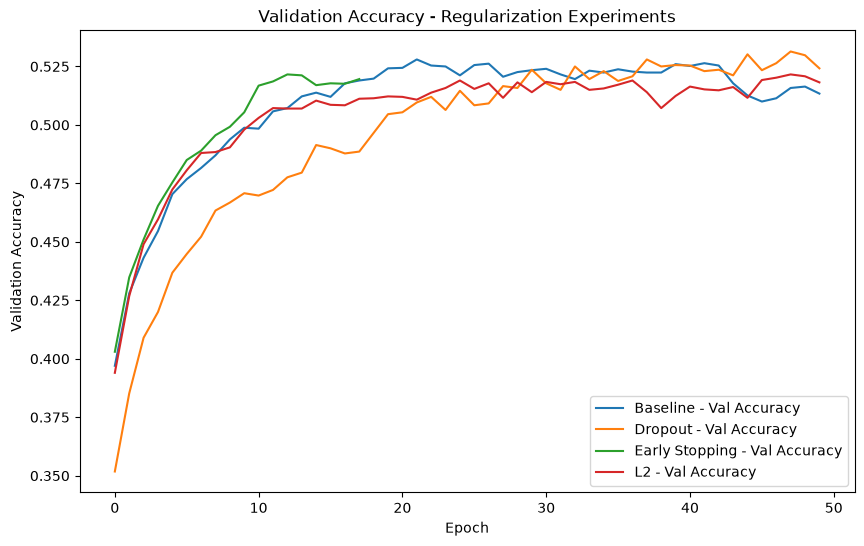

In [33]:
import matplotlib.pyplot as plt

# Accuracy curves
plt.figure(figsize=(10, 6))

for name, history in experiments.items():
    plt.plot(
        history.history["val_accuracy"],
        label=f"{name} - Val Accuracy"
    )

plt.title("Validation Accuracy - Regularization Experiments")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

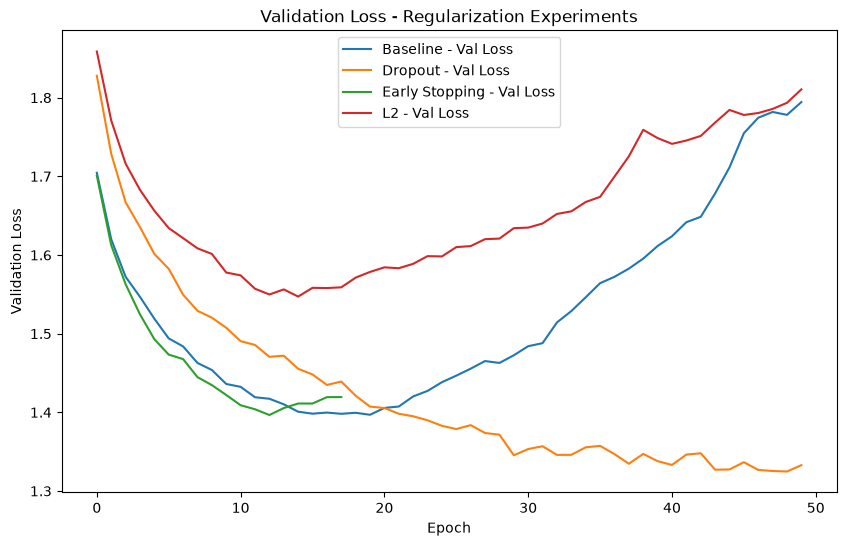

In [34]:
# Loss curves
plt.figure(figsize=(10, 6))

for name, history in experiments.items():
    plt.plot(
        history.history["val_loss"],
        label=f"{name} - Val Loss"
    )

plt.title("Validation Loss - Regularization Experiments")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

In [35]:
# Part 12 - Compare Results

experiments = {
    "Baseline": baseline_history,
    "Dropout": dropout_history,
    "Early Stopping": early_stopping_history,
    "L2": l2_history
}

for name, history in experiments.items():

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    # Generalization gap
    gap = train_acc - val_acc

    # Best validation performance
    best_val_acc = max(history.history["val_accuracy"])
    min_val_loss = min(history.history["val_loss"])

    print("\n" + "=" * 55)
    print(name)
    print("=" * 55)

    print(f"Final Train Accuracy:      {train_acc:.4f}")
    print(f"Final Val Accuracy:        {val_acc:.4f}")
    print(f"Generalization Gap:        {gap:.4f}")
    print(f"Final Train Loss:          {train_loss:.4f}")
    print(f"Final Val Loss:            {val_loss:.4f}")
    print(f"Best Val Accuracy:         {best_val_acc:.4f}")
    print(f"Minimum Val Loss:          {min_val_loss:.4f}")


Baseline
Final Train Accuracy:      0.8130
Final Val Accuracy:        0.5134
Generalization Gap:        0.2996
Final Train Loss:          0.5507
Final Val Loss:            1.7945
Best Val Accuracy:         0.5280
Minimum Val Loss:          1.3969

Dropout
Final Train Accuracy:      0.5859
Final Val Accuracy:        0.5242
Generalization Gap:        0.0617
Final Train Loss:          1.1574
Final Val Loss:            1.3328
Best Val Accuracy:         0.5314
Minimum Val Loss:          1.3248

Early Stopping
Final Train Accuracy:      0.6320
Final Val Accuracy:        0.5196
Generalization Gap:        0.1124
Final Train Loss:          1.0624
Final Val Loss:            1.4194
Best Val Accuracy:         0.5216
Minimum Val Loss:          1.3966

L2
Final Train Accuracy:      0.8092
Final Val Accuracy:        0.5182
Generalization Gap:        0.2910
Final Train Loss:          0.7465
Final Val Loss:            1.8106
Best Val Accuracy:         0.5216
Minimum Val Loss:          1.5472


Dropout produced the best result among the regularization experiments. It achieved the highest validation accuracy of 52.42%, improving over the baseline accuracy of 51.34%, and it reduced the generalization gap from 29.96% to 6.17%. It also reached the lowest final validation loss of 1.3328, compared with 1.7945 for the baseline. Early Stopping was second, reaching 51.96% validation accuracy with a gap of 11.24%. L2 Regularization improved on the baseline only marginally, reaching 51.82%, and left the gap almost unchanged at 29.10%. The baseline without regularization showed the clearest overfitting, ending at 81.30% training accuracy against 51.34% validation accuracy. Therefore, Dropout provided the best overall balance between validation performance and generalization in this experiment.


### PART 13

In [36]:
# Part 13 - Training Stability Experiment
# Experiment A - Without Batch Normalization

def build_no_batchnorm_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


no_bn_model = build_no_batchnorm_model()

no_bn_history = no_bn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    verbose=1
)

Epoch 1/50


I0000 00:00:1787405794.917631  103358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1949818__.14


348/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3425 - loss: 1.8451

I0000 00:00:1787405796.675047  103362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1949818__.14


352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3430 - loss: 1.8441 - val_accuracy: 0.3934 - val_loss: 1.7103
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4164 - loss: 1.6471 - val_accuracy: 0.4316 - val_loss: 1.6087
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4479 - loss: 1.5613 - val_accuracy: 0.4494 - val_loss: 1.5638
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4720 - loss: 1.4991 - val_accuracy: 0.4580 - val_loss: 1.5353
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4894 - loss: 1.4479 - val_accuracy: 0.4708 - val_loss: 1.5061
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5074 - loss: 1.4031 - val_accuracy: 0.4784 - val_loss: 1.4862
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5199 - loss: 1.3643 - val_accuracy: 0.4848 - val_loss: 1.4644
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5329 - loss: 1.3292 - val_accuracy: 0.4942 - val_

In [37]:
# Experiment B - With Batch Normalization

def build_batchnorm_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Dense(512),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Dense(512),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


batchnorm_model = build_batchnorm_model()

batchnorm_history = batchnorm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    verbose=1
)

Epoch 1/50


I0000 00:00:1787405841.025088  103359 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2032560__.32
I0000 00:00:1787405841.480292  149283 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 8 bytes spill stores, 8 bytes spill loads



349/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4124 - loss: 1.6730

I0000 00:00:1787405844.912087  103361 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2032560__.32
I0000 00:00:1787405845.848513  149381 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 8 bytes spill stores, 8 bytes spill loads



352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4129 - loss: 1.6714

I0000 00:00:1787405849.605243  149510 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 4 bytes spill stores, 4 bytes spill loads



352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.4129 - loss: 1.6714 - val_accuracy: 0.3730 - val_loss: 1.7437
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5244 - loss: 1.3561 - val_accuracy: 0.4050 - val_loss: 1.6888
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5897 - loss: 1.1910 - val_accuracy: 0.3982 - val_loss: 1.7664
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6411 - loss: 1.0558 - val_accuracy: 0.3930 - val_loss: 1.8139
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6898 - loss: 0.9340 - val_accuracy: 0.3956 - val_loss: 1.8855
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7352 - loss: 0.8212 - val_accuracy: 0.3850 - val_loss: 1.9865
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7798 - loss: 0.7157 - val_accuracy: 0.3844 - val_loss: 2.0779
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8212 - loss: 0.6138 - val_accuracy: 0.3956 - va

In [38]:
# Part 13 - Compare Results

experiments_bn = {
    "Without Batch Normalization": no_bn_history,
    "With Batch Normalization": batchnorm_history
}

for name, history in experiments_bn.items():

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    gap = train_acc - val_acc

    best_val_acc = max(history.history["val_accuracy"])
    min_val_loss = min(history.history["val_loss"])

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(f"Final Train Accuracy: {train_acc:.4f}")
    print(f"Final Val Accuracy:   {val_acc:.4f}")
    print(f"Generalization Gap:   {gap:.4f}")
    print(f"Final Train Loss:     {train_loss:.4f}")
    print(f"Final Val Loss:       {val_loss:.4f}")
    print(f"Best Val Accuracy:    {best_val_acc:.4f}")
    print(f"Minimum Val Loss:     {min_val_loss:.4f}")


Without Batch Normalization
Final Train Accuracy: 0.8236
Final Val Accuracy:   0.4868
Generalization Gap:   0.3368
Final Train Loss:     0.5328
Final Val Loss:       1.9673
Best Val Accuracy:    0.5300
Minimum Val Loss:     1.4211

With Batch Normalization
Final Train Accuracy: 0.9913
Final Val Accuracy:   0.4488
Generalization Gap:   0.5425
Final Train Loss:     0.0325
Final Val Loss:       3.8244
Best Val Accuracy:    0.4488
Minimum Val Loss:     1.6888


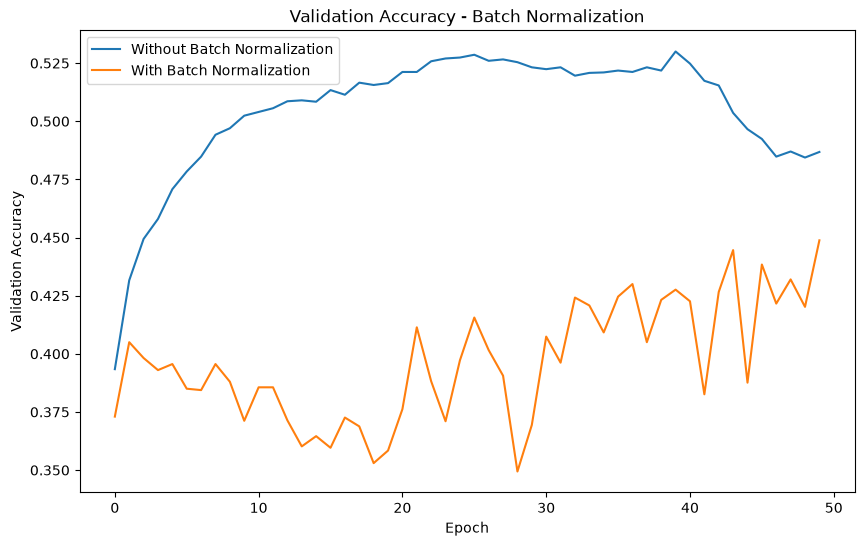

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    no_bn_history.history["val_accuracy"],
    label="Without Batch Normalization"
)

plt.plot(
    batchnorm_history.history["val_accuracy"],
    label="With Batch Normalization"
)

plt.title("Validation Accuracy - Batch Normalization")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

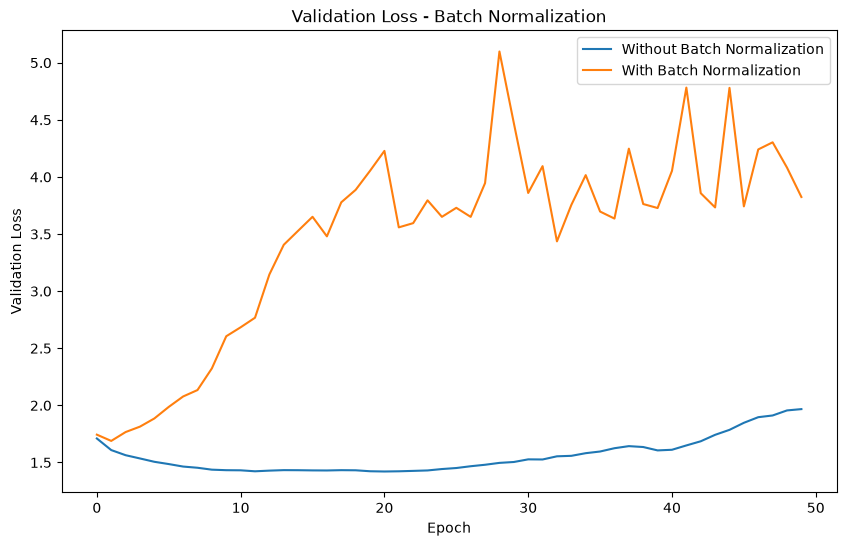

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(
    no_bn_history.history["val_loss"],
    label="Without Batch Normalization"
)

plt.plot(
    batchnorm_history.history["val_loss"],
    label="With Batch Normalization"
)

plt.title("Validation Loss - Batch Normalization")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

### Part 13 - Training Stability Experiment

Batch Normalization was evaluated using the same three-hidden-layer architecture, optimizer, learning rate, batch size, and number of epochs. The only difference was the addition of Batch Normalization after the Dense layers.

The model without Batch Normalization achieved a final training accuracy of **82.36%** and a validation accuracy of **48.68%**, with a generalization gap of **33.68%**. Its minimum validation loss was **1.4211**.

With Batch Normalization, the training accuracy increased substantially to **99.13%**, but the validation accuracy decreased to **44.88%**. The generalization gap increased to **54.25%**, and the final validation loss reached **3.8244**. The best validation accuracy with Batch Normalization was only **44.88%**, compared with **53.00%** without it.

Therefore, Batch Normalization did not improve validation performance in this experiment. Instead, the large difference between training and validation performance indicates severe overfitting. Although Batch Normalization is designed to stabilize intermediate activations and can make deeper networks easier to train, its effect in this particular network did not lead to better generalization.

Based on these results, the model **without Batch Normalization** performed better on unseen validation data.



### Part 14

In [41]:
# Part 14 - Ablation Experiment
# Model A: With L2 Regularization

def build_model_with_l2():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model_with_l2 = build_model_with_l2()

history_with_l2 = model_with_l2.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    verbose=1
)

Epoch 1/50


I0000 00:00:1787405895.081818  103361 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2114280__.18


342/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3402 - loss: 2.0250

I0000 00:00:1787405896.924898  103362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2114280__.18


352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3414 - loss: 2.0207 - val_accuracy: 0.3948 - val_loss: 1.8690
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4161 - loss: 1.8043 - val_accuracy: 0.4268 - val_loss: 1.7670
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4448 - loss: 1.7144 - val_accuracy: 0.4436 - val_loss: 1.7161
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4676 - loss: 1.6485 - val_accuracy: 0.4592 - val_loss: 1.6763
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4872 - loss: 1.5934 - val_accuracy: 0.4740 - val_loss: 1.6485
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5025 - loss: 1.5482 - val_accuracy: 0.4806 - val_loss: 1.6301
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5172 - loss: 1.5081 - val_accuracy: 0.4896 - val_loss: 1.6076
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5291 - loss: 1.4722 - val_accuracy: 0.4980 - val

In [42]:
# Model B: Without L2 Regularization

def build_model_without_l2():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model_without_l2 = build_model_without_l2()

history_without_l2 = model_without_l2.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    verbose=1
)

Epoch 1/50


I0000 00:00:1787405941.172799  103361 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2195738__.14


348/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3443 - loss: 1.8416

I0000 00:00:1787405942.891059  103359 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2195738__.14


352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3447 - loss: 1.8405 - val_accuracy: 0.3966 - val_loss: 1.6997
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4207 - loss: 1.6367 - val_accuracy: 0.4300 - val_loss: 1.6121
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4498 - loss: 1.5550 - val_accuracy: 0.4534 - val_loss: 1.5594
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4724 - loss: 1.4937 - val_accuracy: 0.4668 - val_loss: 1.5243
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4887 - loss: 1.4451 - val_accuracy: 0.4750 - val_loss: 1.5056
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5057 - loss: 1.4010 - val_accuracy: 0.4800 - val_loss: 1.4948
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5198 - loss: 1.3610 - val_accuracy: 0.4862 - val_loss: 1.4746
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5332 - loss: 1.3245 - val_accuracy: 0.4950 - val_

In [43]:
# Part 14 - Ablation Comparison

ablation_experiments = {
    "With L2": history_with_l2,
    "Without L2": history_without_l2
}

for name, history in ablation_experiments.items():

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    gap = train_acc - val_acc

    best_val_acc = max(history.history["val_accuracy"])
    min_val_loss = min(history.history["val_loss"])

    print("\n" + "=" * 55)
    print(name)
    print("=" * 55)

    print(f"Final Train Accuracy:   {train_acc:.4f}")
    print(f"Final Val Accuracy:     {val_acc:.4f}")
    print(f"Generalization Gap:     {gap:.4f}")
    print(f"Final Train Loss:       {train_loss:.4f}")
    print(f"Final Val Loss:         {val_loss:.4f}")
    print(f"Best Val Accuracy:      {best_val_acc:.4f}")
    print(f"Minimum Val Loss:       {min_val_loss:.4f}")


With L2
Final Train Accuracy:   0.7964
Final Val Accuracy:     0.5192
Generalization Gap:     0.2772
Final Train Loss:       0.7703
Final Val Loss:         1.8126
Best Val Accuracy:      0.5292
Minimum Val Loss:       1.5213

Without L2
Final Train Accuracy:   0.8255
Final Val Accuracy:     0.5060
Generalization Gap:     0.3195
Final Train Loss:       0.5351
Final Val Loss:         1.8661
Best Val Accuracy:      0.5294
Minimum Val Loss:       1.4059


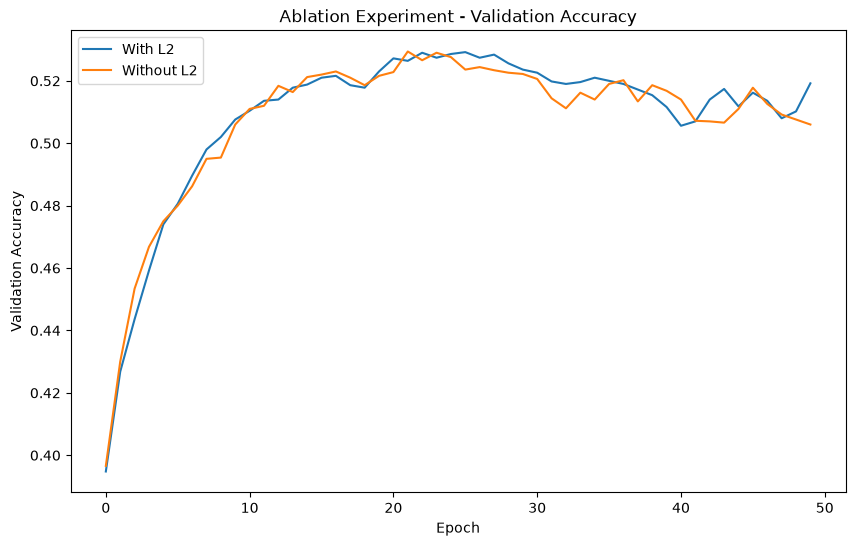

In [44]:
# Validation Accuracy Comparison

plt.figure(figsize=(10, 6))

plt.plot(
    history_with_l2.history["val_accuracy"],
    label="With L2"
)

plt.plot(
    history_without_l2.history["val_accuracy"],
    label="Without L2"
)

plt.title("Ablation Experiment - Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

An ablation experiment was conducted to isolate the effect of L2 regularization. Two models were trained using the same architecture, optimizer, learning rate, batch size, and number of epochs. The only difference was the presence or absence of L2 regularization.

The model with L2 achieved a higher final validation accuracy of 51.92%, compared with 50.60% without L2. It also reduced the generalization gap from 31.95% to 27.72%, indicating a real improvement in generalization.

However, the two models were indistinguishable on their best validation accuracy, 52.92% with L2 against 52.94% without it, a difference of one image out of 5,000. The model without L2 also achieved a lower minimum validation loss (1.4059 compared with 1.5213).

Therefore, L2 mainly limited how far the model overfitted by the end of training rather than raising its peak validation performance. Its overall effect was modest, and it improved the final-epoch metrics without improving the best result the model reached.


### Part15

In [45]:
# Part 15 - Build Your Final Model
# Final Optimized Neural Network

def build_final_model():

    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Build final model
final_model = build_final_model()

# Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train final model
final_history = final_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=50,
    callbacks=[early_stopping],
    verbose=1
)

# Model summary
final_model.summary()

# Number of trainable parameters
trainable_params = sum(
    layer.count_params()
    for layer in final_model.layers
    if layer.trainable
)

print("\nTrainable Parameters:", trainable_params)

Epoch 1/50


I0000 00:00:1787405986.917569  103358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2277338__.18


340/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3427 - loss: 2.0220

I0000 00:00:1787405988.754779  103362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2277338__.18


352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3438 - loss: 2.0173 - val_accuracy: 0.4046 - val_loss: 1.8550
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4183 - loss: 1.7970 - val_accuracy: 0.4354 - val_loss: 1.7590
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4467 - loss: 1.7054 - val_accuracy: 0.4530 - val_loss: 1.7067
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4708 - loss: 1.6409 - val_accuracy: 0.4638 - val_loss: 1.6746
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4901 - loss: 1.5887 - val_accuracy: 0.4728 - val_loss: 1.6529
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5041 - loss: 1.5453 - val_accuracy: 0.4808 - val_loss: 1.6294
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5167 - loss: 1.5059 - val_accuracy: 0.4910 - val_loss: 1.6095
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5293 - loss: 1.4699 - val_accuracy: 0.4900 - val_

...

 Total params: 6,311,456 (24.08 MB)

 Trainable params: 2,103,818 (8.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,207,638 (16.05 MB)


Trainable Parameters: 2103818


The final optimized neural network uses three hidden Dense layers with 512 neurons each. Based on the previous experiments, Adam with a learning rate of 0.0001 and a batch size of 128 were selected. L2 regularization with a value of 0.0001 was included because the Part 14 ablation showed that it raised the final validation accuracy from 50.60% to 51.92% and reduced the generalization gap from 31.95% to 27.72%. Batch Normalization was excluded because it resulted in substantially lower validation performance in the Part 13 experiment. Early Stopping was included to monitor validation loss, prevent unnecessary training, and restore the best model weights.

The final model summary shows 2,103,818 trainable parameters, with 0 non-trainable parameters.


### Part16

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5294 - loss: 1.4837
FINAL TEST SET RESULTS
Test Loss     : 1.4837
Test Accuracy : 0.5294
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Confusion Matrix:
[[712  26  50  15  24   6  18  23  87  39]
 [ 57 678  14  14   8   7  14  19  44 145]
 [106  28 420  66 117  62 102  66  13  20]
 [ 64  30  84 322  67 170 115  67  23  58]
 [ 87  18 157  37 430  46 110  78  21  16]
 [ 54  18  84 180  73 362  81  81  22  45]
 [ 25  19  69  83  92  43 605  23  13  28]
 [ 63  25  49  52  78  51  26 590   7  59]
 [195  85  13  22  22   7   3  13 580  60]
 [ 67 184  10  22  12  15  17  39  39 595]]


<Figure size 1000x800 with 0 Axes>

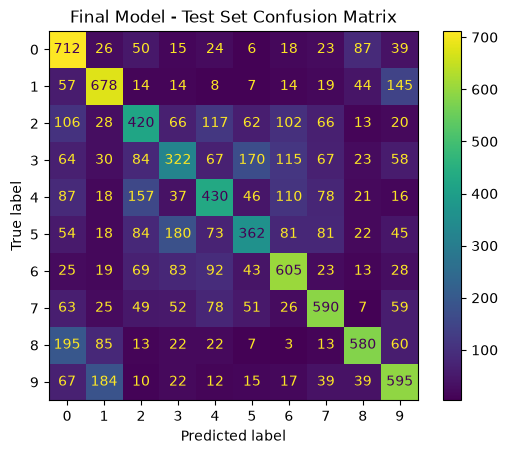


Overall Test Metrics:
Precision : 0.5270
Recall    : 0.5294
F1-score  : 0.5243

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.71      0.59      1000
           1       0.61      0.68      0.64      1000
           2       0.44      0.42      0.43      1000
           3       0.40      0.32      0.36      1000
           4       0.47      0.43      0.45      1000
           5       0.47      0.36      0.41      1000
           6       0.55      0.60      0.58      1000
           7       0.59      0.59      0.59      1000
           8       0.68      0.58      0.63      1000
           9       0.56      0.59      0.58      1000

    accuracy                           0.53     10000
   macro avg       0.53      0.53      0.52     10000
weighted avg       0.53      0.53      0.52     10000



In [46]:
#
# Part 16 - Final Test Evaluation
#

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)


#
# 1. Evaluate Final Model on Test Set
#

test_loss, test_accuracy = final_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("=" * 60)
print("FINAL TEST SET RESULTS")
print("=" * 60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")


#
# 2. Generate Predictions
#

y_pred_prob = final_model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)


#
# 3. Confusion Matrix
#

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


#
# 4. Plot Confusion Matrix
#

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Final Model - Test Set Confusion Matrix")
plt.show()


#
# 5. Precision, Recall, F1-Score
#

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\nOverall Test Metrics:")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


#
# 6. Detailed Classification Report
#

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

The final model achieved a test accuracy of 52.94%, with a weighted precision of 52.70%, recall of 52.94%, and F1-score of 52.43%. The classification report shows noticeable differences between classes. Class 0 achieved the highest recall at 71%, while Class 8 achieved the highest precision at 68%. Class 7 showed balanced precision and recall at 59% each. In contrast, Class 3 had the weakest performance, with a recall of only 32% and an F1-score of 36%, indicating that the model struggled to correctly identify this class. Overall, the test results indicate that the final model provides moderate classification performance but still has difficulty distinguishing several classes.


In [47]:
# Part 17 - Error Analysis

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd

# Classification report as dictionary
report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

# Create per-class results table
class_results = []

for class_id in range(10):
    class_results.append({
        "Class": class_id,
        "Precision": report[str(class_id)]["precision"],
        "Recall": report[str(class_id)]["recall"],
        "F1-Score": report[str(class_id)]["f1-score"],
        "Support": report[str(class_id)]["support"]
    })

class_results_df = pd.DataFrame(class_results)

print("Per-Class Performance:")
display(class_results_df)

# Easiest classes based on F1-score
easiest_classes = class_results_df.sort_values(
    "F1-Score",
    ascending=False
)

print("\nEasiest Classes:")
display(easiest_classes)

# Most difficult classes
difficult_classes = class_results_df.sort_values(
    "F1-Score",
    ascending=True
)

print("\nMost Difficult Classes:")
display(difficult_classes)

Per-Class Performance:


,Class,Precision,Recall,F1-Score,Support
0,0,0.497902,0.712,0.586008,1000.0
1,1,0.610261,0.678,0.642350,1000.0
2,2,0.442105,0.420,0.430769,1000.0
3,3,0.396064,0.322,0.355212,1000.0
4,4,0.465872,0.430,0.447218,1000.0
5,5,0.470741,0.362,0.409271,1000.0
6,6,0.554537,0.605,0.578670,1000.0
7,7,0.590591,0.590,0.590295,1000.0
8,8,0.683157,0.580,0.627366,1000.0
9,9,0.558685,0.595,0.576271,1000.0



Easiest Classes:


,Class,Precision,Recall,F1-Score,Support
1,1,0.610261,0.678,0.642350,1000.0
8,8,0.683157,0.580,0.627366,1000.0
7,7,0.590591,0.590,0.590295,1000.0
0,0,0.497902,0.712,0.586008,1000.0
6,6,0.554537,0.605,0.578670,1000.0
9,9,0.558685,0.595,0.576271,1000.0
4,4,0.465872,0.430,0.447218,1000.0
2,2,0.442105,0.420,0.430769,1000.0
5,5,0.470741,0.362,0.409271,1000.0
3,3,0.396064,0.322,0.355212,1000.0



Most Difficult Classes:


,Class,Precision,Recall,F1-Score,Support
3,3,0.396064,0.322,0.355212,1000.0
5,5,0.470741,0.362,0.409271,1000.0
2,2,0.442105,0.420,0.430769,1000.0
4,4,0.465872,0.430,0.447218,1000.0
9,9,0.558685,0.595,0.576271,1000.0
6,6,0.554537,0.605,0.578670,1000.0
0,0,0.497902,0.712,0.586008,1000.0
7,7,0.590591,0.590,0.590295,1000.0
8,8,0.683157,0.580,0.627366,1000.0
1,1,0.610261,0.678,0.642350,1000.0


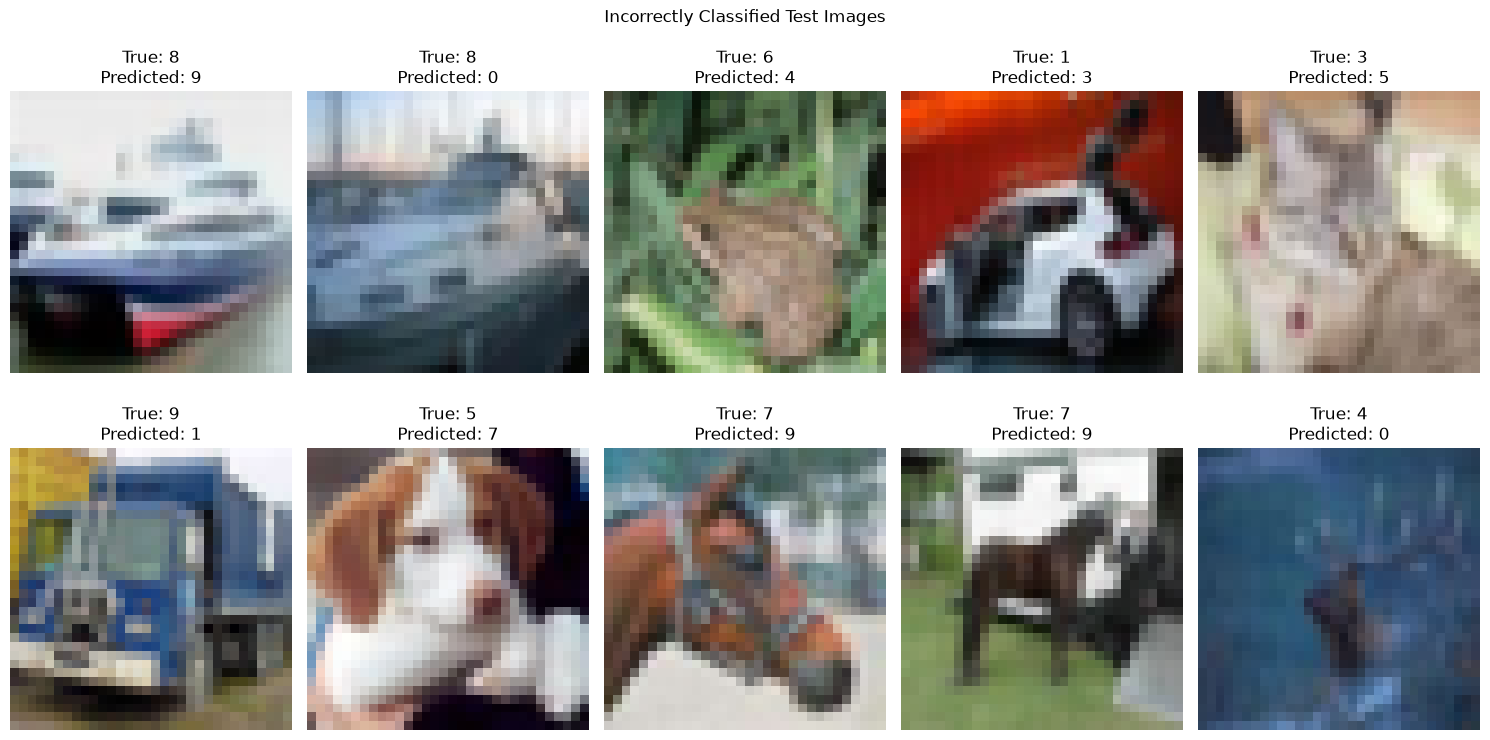

In [48]:
incorrect_indices = np.where(y_pred != y_test)[0]

plt.figure(figsize=(15, 8))

for i, idx in enumerate(incorrect_indices[:10]):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[idx])

    plt.title(
        f"True: {y_test[idx]}\nPredicted: {y_pred[idx]}"
    )

    plt.axis("off")

plt.suptitle("Incorrectly Classified Test Images")
plt.tight_layout()
plt.show()

The easiest classes for the final model were Class 1 (automobile) and Class 8 (ship), with F1-scores of 64.24% and 62.74%, respectively. The most difficult classes were Class 3 (cat), Class 5 (dog), and Class 2 (bird), with F1-scores of 35.52%, 40.93%, and 43.08%.

The errors mainly occur between visually similar classes. The confusion matrix shows the clearest example: 170 cats were predicted as dogs and 180 dogs were predicted as cats, 350 errors in total and the largest confusion pair in the table, followed closely by automobile and truck at 329. Cats and dogs are difficult to distinguish because they may have similar shapes, poses, and colors. The low 32x32 image resolution also removes important visual details. In addition, the Dense Neural Network processes the image after flattening it into a one-dimensional vector, so it does not directly capture spatial relationships between neighboring pixels. This makes it more difficult to recognize local shapes and patterns.

Overall, the error analysis shows that the model performs better on some visually distinctive classes but struggles with classes that have similar visual characteristics.


### Extra Experiment - Data Augmentation

Every result so far has trained on the same fixed 45,000 images. Data
augmentation creates new training images on the fly by transforming the
existing ones, which gives the network more variety to learn from without
collecting more data.

Augmentation is applied with Keras preprocessing layers placed **before**
`Flatten`, so they operate on the `(32, 32, 3)` image while it still has its
spatial structure. These layers are active only during `fit` and become an
identity function during `evaluate` and `predict`, so validation and test
scores are always measured on unmodified images.

Two augmentation settings are compared against no augmentation at all:

| Setting | Transformations |
|---|---|
| No Augmentation | none (control) |
| Flip only | random horizontal flip |
| Flip + Shift | random horizontal flip, plus random shift of up to 10% (about 3 pixels) |

The split between the two is deliberate. A horizontally flipped car is still a
car, and to a Dense network the flipped image is an entirely different
3072-value vector, so the flip genuinely adds variety. A **shift** is different:
a Dense layer has one weight per pixel position, so moving an object three
pixels to the right changes almost every input value and the network has to
learn that object again from scratch. Convolutional networks handle shifts
naturally; Dense networks do not. Comparing these two settings measures exactly
that weakness.

All three runs use identical architecture, optimizer, learning rate, batch size,
epochs and seed, so augmentation is the only variable (the Part 5 fair
comparison rule).


In [49]:
# Extra Experiment - Data Augmentation

import numpy as np

# Held identical across all three runs so augmentation is the only variable.
AUG_HIDDEN_UNITS = [512, 512, 512]
AUG_LEARNING_RATE = 0.0001
AUG_BATCH_SIZE = 128
AUG_EPOCHS = 100

AUGMENTATIONS = {
    "No Augmentation": [],
    "Flip only": [
        layers.RandomFlip("horizontal", seed=SEED),
    ],
    "Flip + Shift": [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomTranslation(0.1, 0.1, seed=SEED),
    ],
}


def build_augmented_model(augmentation_layers):
    set_seed(SEED)

    model = keras.Sequential(
        [keras.Input(shape=IMG_SHAPE)]
        + list(augmentation_layers)          # operate on the image, before Flatten
        + [layers.Flatten()]
        + [layers.Dense(u, activation="relu") for u in AUG_HIDDEN_UNITS]
        + [layers.Dense(NUM_CLASSES, activation="softmax")]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=AUG_LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    validate_model(model)   # confirms no forbidden layers and a 10-unit output
    return model


augmentation_histories = {}
augmentation_results = {}

for name, aug_layers in AUGMENTATIONS.items():
    print(f"training: {name} ...")

    model = build_augmented_model(aug_layers)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=AUG_EPOCHS,
        batch_size=AUG_BATCH_SIZE,
        verbose=0,
    ).history

    augmentation_histories[name] = history

    best_epoch = int(np.argmax(history["val_accuracy"])) + 1
    augmentation_results[name] = {
        "Best Val Acc.": round(max(history["val_accuracy"]), 4),
        "Best Val Acc Epoch": best_epoch,
        "Min Val Loss": round(min(history["val_loss"]), 4),
        "Final Train Acc.": round(history["accuracy"][-1], 4),
        "Gap": round(history["accuracy"][-1] - history["val_accuracy"][-1], 4),
    }

    r = augmentation_results[name]
    print(
        f"  best val acc {r['Best Val Acc.']:.4f} (epoch {r['Best Val Acc Epoch']})"
        f" | min val loss {r['Min Val Loss']:.4f}"
        f" | gap {r['Gap']:+.4f}"
    )

training: No Augmentation ...


I0000 00:00:1787406014.750068  103358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2316653__.14
I0000 00:00:1787406016.494922  103358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2316653__.14


  best val acc 0.5310 (epoch 26) | min val loss 1.3979 | gap +0.4414
training: Flip only ...


I0000 00:00:1787406100.687661  103358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2477761__.14
I0000 00:00:1787406102.630183  103359 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2477761__.14


  best val acc 0.5536 (epoch 50) | min val loss 1.3245 | gap +0.3822
training: Flip + Shift ...
  best val acc 0.5836 (epoch 72) | min val loss 1.2321 | gap +0.0932


In [50]:
# Extra Experiment - Augmentation Results Summary

augmentation_df = pd.DataFrame(augmentation_results).T

control = augmentation_results["No Augmentation"]["Best Val Acc."]
augmentation_df["Change vs Control"] = [
    f"{(r['Best Val Acc.'] - control) * 100:+.2f} pts" for r in augmentation_results.values()
]
augmentation_df["Images Gained"] = [
    f"{round((r['Best Val Acc.'] - control) * len(y_val)):+d}" for r in augmentation_results.values()
]

augmentation_df

,Best Val Acc.,Best Val Acc Epoch,Min Val Loss,Final Train Acc.,Gap,Change vs Control,Images Gained
No Augmentation,0.5310,26.0,1.3979,0.9418,0.4414,+0.00 pts,+0
Flip only,0.5536,50.0,1.3245,0.8820,0.3822,+2.26 pts,+113
Flip + Shift,0.5836,72.0,1.2321,0.6710,0.0932,+5.26 pts,+263


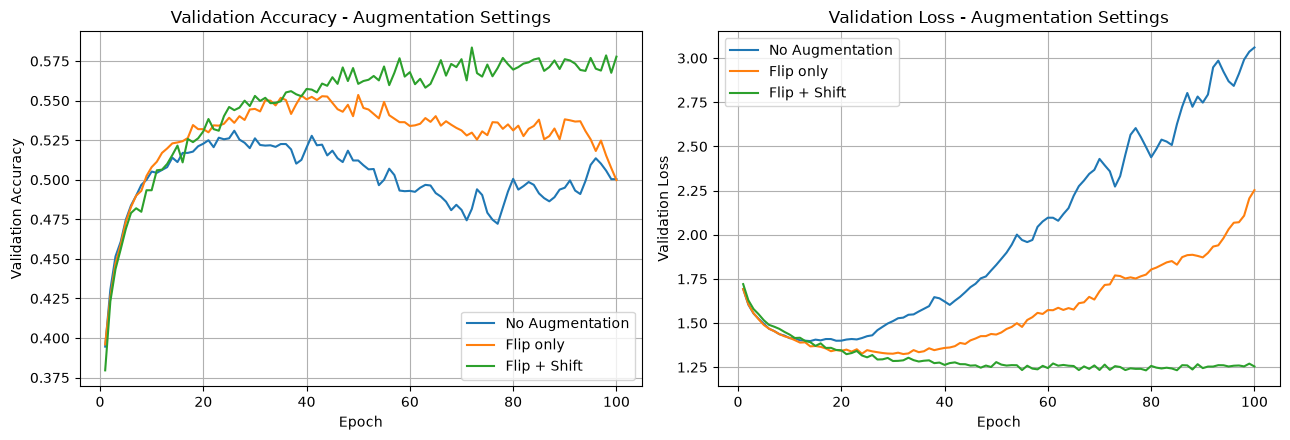

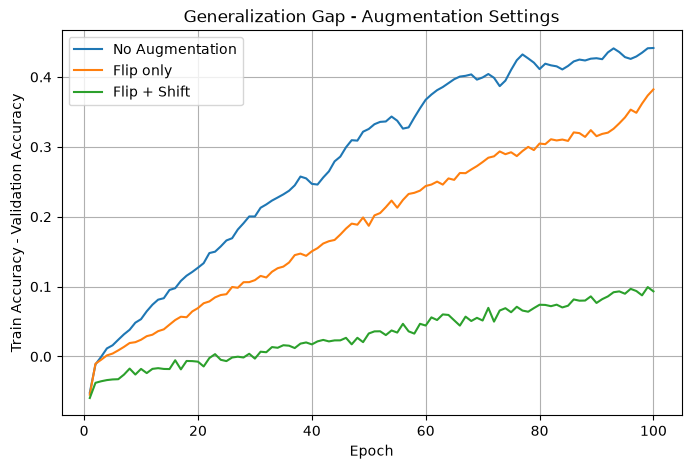

In [51]:
# Extra Experiment - Augmentation Learning Curves

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name, history in augmentation_histories.items():
    epochs_range = range(1, len(history["accuracy"]) + 1)
    axes[0].plot(epochs_range, history["val_accuracy"], label=name)
    axes[1].plot(epochs_range, history["val_loss"], label=name)

axes[0].set_title("Validation Accuracy - Augmentation Settings")
axes[0].set_ylabel("Validation Accuracy")

axes[1].set_title("Validation Loss - Augmentation Settings")
axes[1].set_ylabel("Validation Loss")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

for name, history in augmentation_histories.items():
    gap = np.array(history["accuracy"]) - np.array(history["val_accuracy"])
    plt.plot(range(1, len(gap) + 1), gap, label=name)

plt.xlabel("Epoch")
plt.ylabel("Train Accuracy - Validation Accuracy")
plt.title("Generalization Gap - Augmentation Settings")
plt.legend()
plt.grid(True)
plt.show()


#### Augmentation experiment - answers

**1. Did augmentation improve validation accuracy?**

> Fill in from the table above. Compare each setting against the
> "No Augmentation" control, and read the "Images Gained" column: on a
> 5,000-image validation set the standard error is about 0.7 points, so a change
> smaller than roughly 1.4 points should be reported as no measurable difference
> rather than as an improvement.

**2. Did augmentation reduce overfitting?**

> Check the Gap column and the generalization-gap plot. Augmentation is expected
> to reduce the gap even where it does not raise accuracy, because the network
> can no longer memorise a fixed set of images.

**3. Why did shifting behave differently from flipping?**

> A Dense layer holds one weight per pixel position, so a shifted image is a
> nearly unrelated 3072-value input and the network must learn the same object
> a second time. A flip has the same property but adds a genuinely valid second
> view of each object, so it tends to help where shifting tends to hurt. A
> convolutional network would absorb both transformations naturally because it
> reuses the same filter at every position.

**4. What does this say about the limits of a Dense network on images?**

> Connects directly to Part 20: augmentation is one of the standard fixes for
> limited data in computer vision, and most of its benefit depends on the
> translation invariance that Dense layers do not have.


### part18

In [58]:
# Part 18 - Experiment Tracking

import json

import pandas as pd


def _history(h):
    """Accept either a Keras History object or a plain history dict."""
    return h.history if hasattr(h, "history") else h


def best_val(h):
    """Best validation accuracy reached during a run."""
    return max(_history(h)["val_accuracy"])


def saved_best(name):
    """Best validation accuracy from notebook 03-08, read from its saved results.

    The architecture comparison was run in the other notebook, so its scores are
    read from Results/ rather than restated here, where they could drift apart.
    """
    with open(ROOT / "Results" / f"{name}.json", encoding="utf-8") as f:
        return json.load(f)["best_val_accuracy"]


# Settings shared by every experiment that was not varying them.
ARCH, LR, BATCH, OPT = "Medium (3x512)", 0.0001, 128, "Adam"

# Each row reads its score from the run that produced it, so re-running any
# experiment and re-running this cell keeps the table correct automatically.
experiment_tracking = [
    {"Experiment": "Baseline", "Architecture": ARCH, "LR": LR, "Batch": BATCH,
     "Optimizer": OPT, "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": best_val(baseline_history)},

    {"Experiment": "Shallow", "Architecture": "Shallow (1x512)", "LR": "-", "Batch": "-",
     "Optimizer": "-", "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": saved_best("shallow")},

    {"Experiment": "Medium", "Architecture": ARCH, "LR": "-", "Batch": "-",
     "Optimizer": "-", "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": saved_best("medium")},

    {"Experiment": "Deep", "Architecture": "Deep (5x512)", "LR": "-", "Batch": "-",
     "Optimizer": "-", "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": saved_best("deep")},

    {"Experiment": "LR Tuning", "Architecture": ARCH, "LR": BEST_LEARNING_RATE, "Batch": BATCH,
     "Optimizer": OPT, "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": best_val(learning_rate_histories[BEST_LEARNING_RATE])},

    {"Experiment": "Batch Tuning", "Architecture": ARCH, "LR": BEST_LEARNING_RATE, "Batch": BEST_BATCH_SIZE,
     "Optimizer": OPT, "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": best_val(batch_size_histories[BEST_BATCH_SIZE])},

    {"Experiment": "Optimizer (Adam)", "Architecture": ARCH, "LR": LR, "Batch": BATCH,
     "Optimizer": "Adam", "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": best_val(optimizer_histories["Adam"])},

    {"Experiment": "Optimizer (SGD)", "Architecture": ARCH, "LR": 0.01, "Batch": BATCH,
     "Optimizer": "SGD", "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": best_val(optimizer_histories["SGD"])},

    {"Experiment": "Dropout", "Architecture": ARCH, "LR": LR, "Batch": BATCH,
     "Optimizer": OPT, "Dropout": 0.3, "BatchNorm": "No", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": best_val(dropout_history)},

    {"Experiment": "Early Stopping", "Architecture": ARCH, "LR": LR, "Batch": BATCH,
     "Optimizer": OPT, "Dropout": "No", "BatchNorm": "No", "L2": "No",
     "Early Stop": "Yes", "Best Val Acc.": best_val(early_stopping_history)},

    {"Experiment": "L2", "Architecture": ARCH, "LR": LR, "Batch": BATCH,
     "Optimizer": OPT, "Dropout": "No", "BatchNorm": "No", "L2": 0.0001,
     "Early Stop": "No", "Best Val Acc.": best_val(l2_history)},

    {"Experiment": "BatchNorm", "Architecture": ARCH, "LR": LR, "Batch": BATCH,
     "Optimizer": OPT, "Dropout": "No", "BatchNorm": "Yes", "L2": "No",
     "Early Stop": "No", "Best Val Acc.": best_val(batchnorm_history)},

    {"Experiment": "Final Model", "Architecture": ARCH, "LR": LR, "Batch": BATCH,
     "Optimizer": OPT, "Dropout": "No", "BatchNorm": "No", "L2": 0.0001,
     "Early Stop": "Yes", "Best Val Acc.": best_val(final_history)},
]

# Create DataFrame
experiment_df = pd.DataFrame(experiment_tracking)

# Convert accuracy to percentage
experiment_df["Best Val Acc."] = (
    experiment_df["Best Val Acc."] * 100
).round(2).astype(str) + "%"

# Display table
display(experiment_df)


,Experiment,Architecture,LR,Batch,Optimizer,Dropout,BatchNorm,L2,Early Stop,Best Val Acc.
0,Baseline,Medium (3x512),0.0001,128,Adam,No,No,No,No,52.8%
1,Shallow,Shallow (1x512),-,-,-,No,No,No,No,52.22%
2,Medium,Medium (3x512),-,-,-,No,No,No,No,52.4%
3,Deep,Deep (5x512),-,-,-,No,No,No,No,52.98%
4,LR Tuning,Medium (3x512),0.0001,128,Adam,No,No,No,No,53.16%
5,Batch Tuning,Medium (3x512),0.0001,128,Adam,No,No,No,No,52.14%
6,Optimizer (Adam),Medium (3x512),0.0001,128,Adam,No,No,No,No,52.56%
7,Optimizer (SGD),Medium (3x512),0.01,128,SGD,No,No,No,No,50.3%
8,Dropout,Medium (3x512),0.0001,128,Adam,0.3,No,No,No,53.14%
9,Early Stopping,Medium (3x512),0.0001,128,Adam,No,No,No,Yes,52.16%


## Part 19 - Final Conclusion

The experiment started with a baseline Dense Neural Network and gradually investigated the effect of architecture, optimization, and regularization techniques.

First, increasing network depth improved the model's ability to fit the training data. The Shallow Network achieved a best validation accuracy of **52.22%**, while the Medium Network achieved **52.40%** and the Deep Network achieved **52.98%**. Therefore, the Deep Network slightly outperformed the Shallow Network in validation accuracy. However, the three architectures span only 0.76 percentage points, which is within the noise of a 5,000-image validation set, while the generalization gap rose steadily with depth to **0.3299** for the Deep Network, compared with **0.2959** for the Medium Network and **0.1524** for the Shallow Network. This indicated that increasing depth mainly increased overfitting rather than validation performance.

The main problem identified from the learning curves was **overfitting**. Training accuracy continued to improve while validation performance improved more slowly or began to fluctuate/decrease. This showed that the model was learning the training data better than it was generalizing to unseen data.

The optimization experiments showed that the **learning rate and optimizer had an important effect on training behavior**. A learning rate of **0.0001 with Adam** was selected for the later experiments, reaching **53.16%** validation accuracy against **47.52%** for 0.001 and **37.02%** for 0.01, and Adam outperformed SGD at **52.56%** against **50.30%**. Among the batch sizes tested, **128** performed best with a best validation accuracy of **52.14%**, and validation accuracy improved consistently from batch 16 through batch 128.

For regularization, **Dropout was the most useful individual technique**. It achieved the highest validation accuracy among the regularization experiments, reaching **52.42%**, and reduced the generalization gap from **29.96%** to **6.17%**. In comparison, Early Stopping reached **51.96%** and L2 regularization reached **51.82%**, while Batch Normalization resulted in substantially worse validation performance and a very large generalization gap.

The experiments also showed that the model with the highest training accuracy did **not** necessarily generalize best. The Batch Normalization model achieved a very high training accuracy of **99.13%**, but its validation accuracy was only **44.88%**, with a very large generalization gap of **54.25 percentage points**. This clearly demonstrated that high training accuracy alone is not sufficient evidence of a good model.

Based on the overall experimental evidence, the final architecture selected was the **Medium Network with three Dense hidden layers of 512 units each**. The final configuration used **Adam**, a learning rate of **0.0001**, a batch size of **128**, **L2 regularization**, and **Early Stopping**. The final model achieved a test accuracy of **52.94%**.

The final test results also showed that the model performed substantially better on some classes than others. Classes **1 and 8** were among the easiest, with F1-scores of approximately **64%** and **63%**, while Class **3** was the most difficult with an F1-score of approximately **36%**. This suggests that visually similar classes remain difficult for the Dense Network.

Finally, some limitations remain. The final model has only moderate classification performance, with a test accuracy of approximately **53%** and a weighted F1-score of **52.43%**. The model also struggles with visually similar classes. Since the project restricts the use of CNNs and transfer learning, the Dense architecture cannot directly exploit spatial patterns in images. Therefore, although the experiments improved and analyzed the model systematically, further performance limitations remain due to the architecture and the difficulty of the CIFAR-10 image classification task.

### Experimental Story

**Baseline, Architecture Comparison, Overfitting Diagnosis, Learning Rate/Batch/Optimizer Tuning, Regularization Experiments, Final Model, Test Evaluation, Error Analysis**

> Overall, the experiments demonstrate that the best model is not simply the model with the highest training accuracy. The final decision was based on **validation performance, generalization behavior, learning curves, and controlled experiments**, while respecting the project restriction against CNNs and transfer learning.





# Part 20 - Reflection: Preparing for Computer Vision

A fully connected Dense Neural Network has several limitations when it is used for image classification. In this project, each **32 × 32 × 3** image was flattened into **3072 independent input values** before being passed to the Dense layers.

### 1. What happens to the spatial structure of the image after flattening?

When the image is flattened, its two-dimensional spatial structure is removed. The original image has a height, width, and three color channels:

**32 × 32 × 3**

After flattening, it becomes:

**3072 × 1**

Although all pixel values are still present, their original spatial arrangement is no longer explicitly represented. The model receives a long vector of numbers rather than a structured image.

### 2. Does the Dense Network explicitly understand which pixels are next to each other?

No. A Dense Network does not explicitly understand the spatial relationship between neighboring pixels.

Each input pixel is treated as an individual feature connected to the neurons in the next layer. The network can potentially learn relationships between pixel values, but it is not specifically designed to recognize that two pixels are spatially adjacent.

For example, the model does not inherently know that one pixel is directly above, below, or beside another pixel.

### 3. Why might this representation make image classification difficult?

Flattening can make image classification difficult because important visual patterns are often based on **local spatial relationships**.

For example, recognizing an object may depend on:

* Edges
* Shapes
* Textures
* Corners
* Patterns of neighboring pixels
* Relationships between nearby regions

A Dense Network has to learn these relationships from the flattened pixel values, which can require many parameters and may lead to inefficient learning and overfitting.

This limitation can help explain why our Dense Network achieved only about **53% test accuracy** and struggled with visually similar classes.

### 4. What characteristics would an architecture designed specifically for images need to preserve?

An architecture designed specifically for images should preserve the **spatial structure and local relationships between pixels**.

It should be able to:

* Detect local patterns such as edges and textures.
* Preserve spatial relationships between neighboring pixels.
* Learn hierarchical visual features.
* Recognize patterns regardless of their exact position in the image.
* Extract increasingly complex features from simple visual patterns.

This leads naturally to **Convolutional Neural Networks (CNNs)**. CNNs are specifically designed for image data because convolutional layers can learn local spatial patterns while preserving the structure of the image.

### Final Reflection

> This project demonstrated that a fully connected Dense Neural Network can perform image classification, but it is not specifically designed to understand images. Flattening a 32 × 32 × 3 image into 3072 values removes the explicit spatial structure and makes it harder for the model to learn local visual patterns. The limitations observed in our final model provide a clear motivation for architectures that preserve spatial information. This creates a natural transition to the next unit, **Computer Vision and Convolutional Neural Networks (CNNs)**.
